<a href="https://colab.research.google.com/github/abroraxatov1/dataset1/blob/main/TabNet%20model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("https://raw.githubusercontent.com/abroraxatov1/soil_dataset/refs/heads/main/seven_crop.csv")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18346 entries, 0 to 18345
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Sample                  16307 non-null  object 
 1   Layer (sm)              18092 non-null  object 
 2   Mechanical composition  17982 non-null  object 
 3   CF (%)                  17893 non-null  float64
 4   Soil Density (g/cm³)    17814 non-null  float64
 5   pH                      17967 non-null  float64
 6   EC (mS/cm)              17854 non-null  float64
 7   N (mg/kg)               17966 non-null  float64
 8   P (mg/kg)               17945 non-null  float64
 9   K (mg/kg)               17995 non-null  float64
 10  Humus (%)               17837 non-null  float64
 11  Mg (mg/kg)              17882 non-null  float64
 12  S (mg/kg)               17848 non-null  float64
 13  Zn (mg/kg)              17641 non-null  float64
 14  Mn (mg/kg)              17722 non-null

In [ ]:
df.head()

,Sample,Layer (sm),Mechanical composition,CF (%),Soil Density (g/cm³),pH,EC (mS/cm),N (mg/kg),P (mg/kg),K (mg/kg),Humus (%),Mg (mg/kg),S (mg/kg),Zn (mg/kg),Mn (mg/kg),B (mg/kg),Fe (mg/kg),Cu (mg/kg),Microorganisms (CFU/g),Crop
0,NaN,40-60,Loamy,25.712807,1.457113,7.937305,2.314010,14.730419,8.522521,149.053614,0.608170,191.606107,14.281694,57.778321,87.646882,0.420984,96.509662,12.516341,1267278.0,Wheat
1,NaN,40-60,Loamy,25.433538,1.464649,6.246307,1.821689,82.620026,69.432481,253.167410,2.593501,111.327086,20.601440,39.687666,46.070441,1.540358,147.093984,11.615279,77076271.0,Corn
2,NaN,20-40,Clay,23.689499,NaN,8.289166,2.013845,14.648041,7.270005,115.110419,0.465548,155.009343,9.057294,21.729273,119.843093,1.064296,136.168008,15.113455,418065.0,NaN
3,407,0-20,Clay,31.897131,NaN,7.040737,1.658389,162.834909,73.458159,252.186845,2.475862,191.849055,29.624305,42.607224,118.275093,1.651026,260.485571,21.478858,56876960.0,Corn
4,408,20-40,Sand,26.628374,NaN,7.323268,1.518346,120.695096,63.034031,214.797463,2.329035,121.493596,32.524197,59.549807,95.159108,1.176211,242.888489,18.562968,11331527.0,NaN


In [ ]:
from sklearn.preprocessing import OrdinalEncoder

categorical_cols = df.select_dtypes(include=['object', 'category']).columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
df[categorical_cols] = encoder.fit_transform(df[categorical_cols])
df.head(10)

,Sample,Layer (sm),Mechanical composition,CF (%),Soil Density (g/cm³),pH,EC (mS/cm),N (mg/kg),P (mg/kg),K (mg/kg),Humus (%),Mg (mg/kg),S (mg/kg),Zn (mg/kg),Mn (mg/kg),B (mg/kg),Fe (mg/kg),Cu (mg/kg),Microorganisms (CFU/g),Crop
0,NaN,2.0,2.0,25.712807,1.457113,7.937305,2.314010,14.730419,8.522521,149.053614,0.608170,191.606107,14.281694,57.778321,87.646882,0.420984,96.509662,12.516341,1267278.0,6.0
1,NaN,2.0,2.0,25.433538,1.464649,6.246307,1.821689,82.620026,69.432481,253.167410,2.593501,111.327086,20.601440,39.687666,46.070441,1.540358,147.093984,11.615279,77076271.0,2.0
2,NaN,1.0,0.0,23.689499,NaN,8.289166,2.013845,14.648041,7.270005,115.110419,0.465548,155.009343,9.057294,21.729273,119.843093,1.064296,136.168008,15.113455,418065.0,NaN
3,310.0,0.0,0.0,31.897131,NaN,7.040737,1.658389,162.834909,73.458159,252.186845,2.475862,191.849055,29.624305,42.607224,118.275093,1.651026,260.485571,21.478858,56876960.0,2.0
4,311.0,1.0,3.0,26.628374,NaN,7.323268,1.518346,120.695096,63.034031,214.797463,2.329035,121.493596,32.524197,59.549807,95.159108,1.176211,242.888489,18.562968,11331527.0,NaN
5,3010.0,2.0,0.0,28.421633,1.317332,6.965186,1.889373,106.875007,58.861916,239.442310,2.488569,83.391339,28.794054,40.371494,132.194815,0.576151,128.032981,7.917830,5970142.0,NaN
6,1429.0,2.0,0.0,29.104141,1.425908,7.168897,1.304957,122.759085,63.686259,187.465613,1.992496,90.810572,20.538690,20.728787,69.223313,NaN,131.862553,17.395514,29416652.0,2.0
7,1438.0,NaN,0.0,30.521555,1.311800,6.677585,2.547946,NaN,NaN,115.717121,1.245048,140.713807,19.297699,46.311613,127.801523,NaN,110.472875,18.863774,38180921.0,3.0
8,3184.0,NaN,0.0,22.734376,1.226536,6.871183,1.386054,NaN,NaN,129.924037,1.017276,NaN,17.205742,3.792234,13.803035,NaN,21.885743,2.176562,NaN,1.0
9,3329.0,NaN,0.0,33.414945,1.340843,7.050677,2.796166,NaN,NaN,137.577791,1.163247,158.390184,17.473293,26.853845,128.098436,NaN,160.156425,12.001256,43102111.0,3.0


In [ ]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# Categorical ustunlar uchun classifier
categorical_cols = ['Sample', 'Layer (sm)', 'Mechanical composition', 'Crop']

imp = IterativeImputer(
    estimator=ExtraTreesClassifier(n_estimators=50, random_state=42),
    max_iter=10,
    initial_strategy='most_frequent',
    random_state=42
)
df[categorical_cols] = imp.fit_transform(df[categorical_cols])

In [ ]:
df.head()

,Sample,Layer (sm),Mechanical composition,CF (%),Soil Density (g/cm³),pH,EC (mS/cm),N (mg/kg),P (mg/kg),K (mg/kg),Humus (%),Mg (mg/kg),S (mg/kg),Zn (mg/kg),Mn (mg/kg),B (mg/kg),Fe (mg/kg),Cu (mg/kg),Microorganisms (CFU/g),Crop
0,2963.0,2.0,2.0,25.712807,1.457113,7.937305,2.314010,14.730419,8.522521,149.053614,0.608170,191.606107,14.281694,57.778321,87.646882,0.420984,96.509662,12.516341,1267278.0,6.0
1,387.0,2.0,2.0,25.433538,1.464649,6.246307,1.821689,82.620026,69.432481,253.167410,2.593501,111.327086,20.601440,39.687666,46.070441,1.540358,147.093984,11.615279,77076271.0,2.0
2,2063.0,1.0,0.0,23.689499,NaN,8.289166,2.013845,14.648041,7.270005,115.110419,0.465548,155.009343,9.057294,21.729273,119.843093,1.064296,136.168008,15.113455,418065.0,0.0
3,310.0,0.0,0.0,31.897131,NaN,7.040737,1.658389,162.834909,73.458159,252.186845,2.475862,191.849055,29.624305,42.607224,118.275093,1.651026,260.485571,21.478858,56876960.0,2.0
4,311.0,1.0,3.0,26.628374,NaN,7.323268,1.518346,120.695096,63.034031,214.797463,2.329035,121.493596,32.524197,59.549807,95.159108,1.176211,242.888489,18.562968,11331527.0,5.0


In [ ]:
!pip install fancyimpute


  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 6.7 MB/s eta 0:00:00
  Created wheel for fancyimpute: filename=fancyimpute-0.7.0-py3-none-any.whl size=29879 sha256=1de9965835809e35889d27a57625c9bc6c52802237a96fb4d1e2f659b6a18b2a
  Stored in directory: /root/.cache/pip/wheels/df/20/91/e4850b9a31cf660c1bc95515d3bcbc8010e869e5de6d5baf07
  Created wheel for knnimpute: filename=knnimpute-0.1.0-py3-none-any.whl size=11331 sha256=a9a4a42492f5d7f6021454738de3d8636f94983ebdb0e25defd70dbcd323320d
  Stored in directory: /root/.cache/pip/wheels/89/11/61/aa5a3167bfff49218cd043a73a83034b9eadd858b0059521be
Successfully built fancyimpute knnimpute


In [ ]:
import pandas as pd
import numpy as np
from fancyimpute import IterativeSVD

# df – categorical ustunlar imputatsiya qilingan DataFrame
# faqat numeric ustunlar MF uchun
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
df_numeric = df[numeric_cols]

# IterativeSVD yordamida imputatsiya
svd_imputer = IterativeSVD(rank=12, convergence_threshold=1e-5, max_iters=10)
df_numeric_imputed = svd_imputer.fit_transform(df_numeric)

# DataFrame sifatida qaytarish
df[numeric_cols] = pd.DataFrame(df_numeric_imputed, columns=numeric_cols, index=df.index)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[IterativeSVD] Iter 1: observed MAE=126.347420
[IterativeSVD] Iter 2: observed MAE=22.752523
[IterativeSVD] Iter 3: observed MAE=11.442321
[IterativeSVD] Iter 4: observed MAE=2.543037
[IterativeSVD] Iter 5: observed MAE=0.466729
[IterativeSVD] Iter 6: observed MAE=0.466792


In [ ]:
df.head()

,Sample,Layer (sm),Mechanical composition,CF (%),Soil Density (g/cm³),pH,EC (mS/cm),N (mg/kg),P (mg/kg),K (mg/kg),Humus (%),Mg (mg/kg),S (mg/kg),Zn (mg/kg),Mn (mg/kg),B (mg/kg),Fe (mg/kg),Cu (mg/kg),Microorganisms (CFU/g),Crop
0,2963.0,2.0,2.0,25.712807,1.457113,7.937305,2.314010,14.730419,8.522521,149.053614,0.608170,191.606107,14.281694,57.778321,87.646882,0.420984,96.509662,12.516341,1267278.0,6.0
1,387.0,2.0,2.0,25.433538,1.464649,6.246307,1.821689,82.620026,69.432481,253.167410,2.593501,111.327086,20.601440,39.687666,46.070441,1.540358,147.093984,11.615279,77076271.0,2.0
2,2063.0,1.0,0.0,23.689499,0.122849,8.289166,2.013845,14.648041,7.270005,115.110419,0.465548,155.009343,9.057294,21.729273,119.843093,1.064296,136.168008,15.113455,418065.0,0.0
3,310.0,0.0,0.0,31.897131,0.864834,7.040737,1.658389,162.834909,73.458159,252.186845,2.475862,191.849055,29.624305,42.607224,118.275093,1.651026,260.485571,21.478858,56876960.0,2.0
4,311.0,1.0,3.0,26.628374,0.631225,7.323268,1.518346,120.695096,63.034031,214.797463,2.329035,121.493596,32.524197,59.549807,95.159108,1.176211,242.888489,18.562968,11331527.0,5.0


In [ ]:
df.to_excel('dataset.xlsx', index=False)

In [ ]:
from google.colab import files
files.download('dataset.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install pytorch_tabnet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.7 MB/s eta 0:00:00


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18346 entries, 0 to 18345
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Sample                  18346 non-null  float64
 1   Layer (sm)              18346 non-null  float64
 2   Mechanical composition  18346 non-null  float64
 3   CF (%)                  18346 non-null  float64
 4   Soil Density (g/cm³)    18346 non-null  float64
 5   pH                      18346 non-null  float64
 6   EC (mS/cm)              18346 non-null  float64
 7   N (mg/kg)               18346 non-null  float64
 8   P (mg/kg)               18346 non-null  float64
 9   K (mg/kg)               18346 non-null  float64
 10  Humus (%)               18346 non-null  float64
 11  Mg (mg/kg)              18346 non-null  float64
 12  S (mg/kg)               18346 non-null  float64
 13  Zn (mg/kg)              18346 non-null  float64
 14  Mn (mg/kg)              18346 non-null

epoch 0  | loss: 1.16391 | train_logloss: 8.04094 | train_accuracy: 0.22922 | val_logloss: 8.10225 | val_accuracy: 0.23406 |  0:00:04s
epoch 1  | loss: 0.59743 | train_logloss: 6.43408 | train_accuracy: 0.32713 | val_logloss: 6.40363 | val_accuracy: 0.31635 |  0:00:07s
epoch 2  | loss: 0.48495 | train_logloss: 4.45329 | train_accuracy: 0.39684 | val_logloss: 4.36951 | val_accuracy: 0.40054 |  0:00:10s
epoch 3  | loss: 0.44757 | train_logloss: 3.21104 | train_accuracy: 0.55546 | val_logloss: 3.19545 | val_accuracy: 0.55368 |  0:00:13s
epoch 4  | loss: 0.41943 | train_logloss: 2.33043 | train_accuracy: 0.61543 | val_logloss: 2.38398 | val_accuracy: 0.60817 |  0:00:16s
epoch 5  | loss: 0.38689 | train_logloss: 1.34604 | train_accuracy: 0.68772 | val_logloss: 1.41701 | val_accuracy: 0.68174 |  0:00:18s
epoch 6  | loss: 0.37119 | train_logloss: 0.55445 | train_accuracy: 0.79974 | val_logloss: 0.61234 | val_accuracy: 0.77684 |  0:00:21s
epoch 7  | loss: 0.36704 | train_logloss: 0.48903 | tra

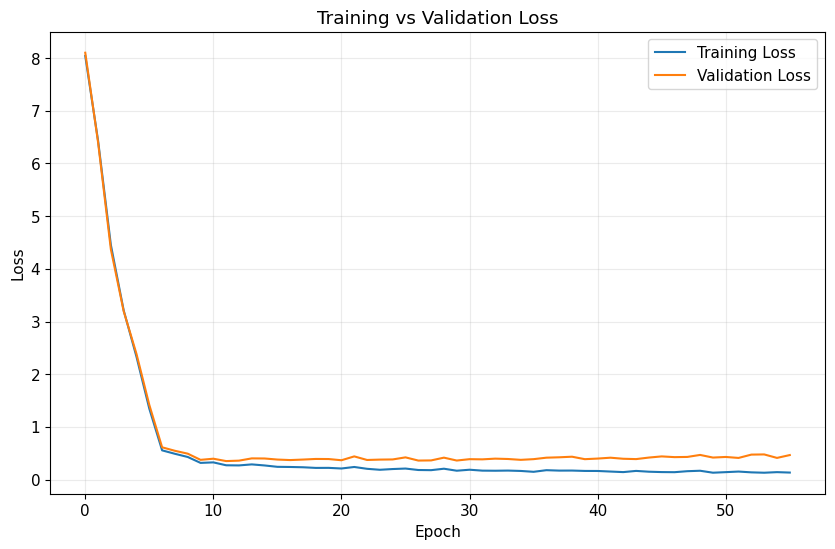

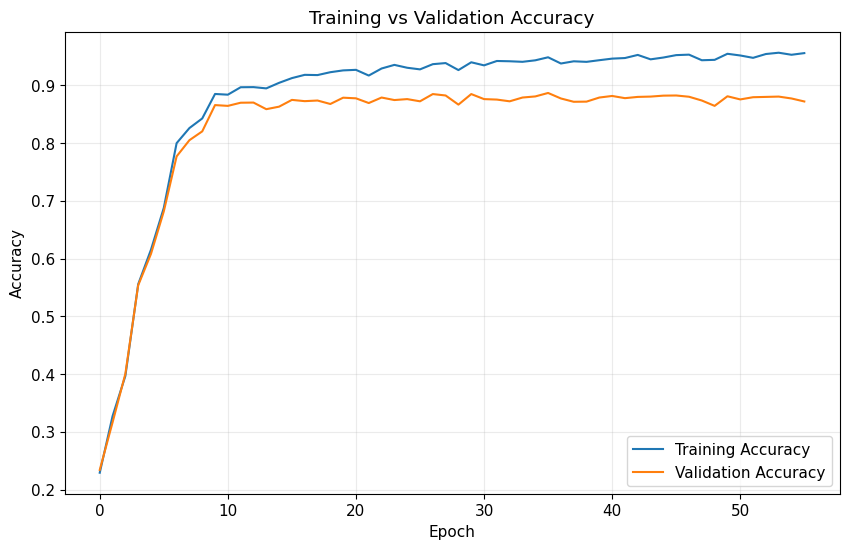

              precision    recall  f1-score   support

           0       0.89      0.90      0.90       523
           1       0.89      0.92      0.90       548
           2       0.92      0.85      0.89       565
           3       0.89      0.96      0.92       581
           4       0.85      0.78      0.81       442
           5       0.82      0.83      0.82       471
           6       0.93      0.94      0.93       540

    accuracy                           0.89      3670
   macro avg       0.88      0.88      0.88      3670
weighted avg       0.89      0.89      0.89      3670



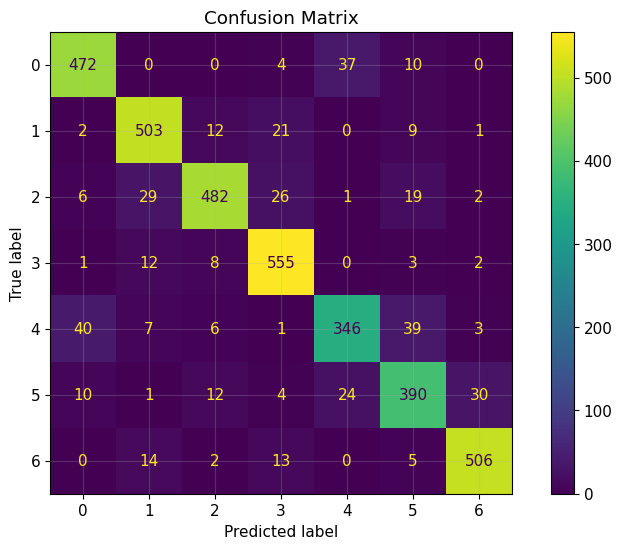

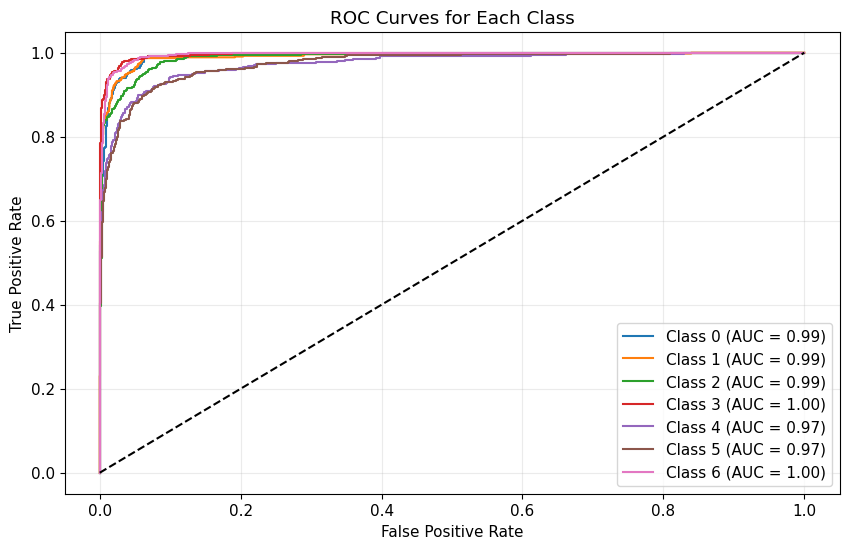

In [ ]:
from pytorch_tabnet.tab_model import TabNetClassifier
import torch
from sklearn.utils.class_weight import compute_class_weight

# Identify categorical columns that are features (excluding the target 'Crop')
# These columns were identified as categorical during preprocessing and ordinal encoding.
feature_categorical_cols = ['Sample', 'Layer (sm)', 'Mechanical composition']

# Create a temporary DataFrame for X to get correct column indices
X_temp = df.drop('Crop', axis=1)

# Get indices of categorical features within X_temp
cat_idxs = [X_temp.columns.get_loc(col) for col in feature_categorical_cols]

# Get the number of unique values (cardinality) for each categorical feature
# based on the encoded values in the original DataFrame.
cat_dims = [df[col].nunique() for col in feature_categorical_cols]

model = TabNetClassifier(
    cat_idxs=cat_idxs,
    cat_dims=cat_dims,
    cat_emb_dim=4,
    n_d=32,
    n_a=32,
    n_steps=3,
    gamma=1.2,
    lambda_sparse=1e-6,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=5e-2),
    mask_type='sparsemax',
    verbose=1

)

from sklearn.model_selection import train_test_split

X = df.drop('Crop', axis=1).values # Convert to numpy array
y = df['Crop'].values.astype(int) # Convert to numpy array and ensure integer type for classification

# FIX: Remove .values as X and y are already numpy arrays
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model.fit(
    X_train=X_train,
    y_train=y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    eval_name=['train', 'val'],
    eval_metric=['logloss', 'accuracy'], # FIX: Added 'accuracy' to eval_metric
    max_epochs=100,
    patience=20,
    batch_size=512,
    virtual_batch_size=128,
    num_workers=1,
    drop_last=False
)

import matplotlib.pyplot as plt

plt.figure()
plt.plot(model.history['train_logloss'], label='Training Loss')
plt.plot(model.history['val_logloss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

plt.figure()
plt.plot(model.history['train_accuracy'], label='Training Accuracy')
plt.plot(model.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(X_val)

print(classification_report(y_val, y_pred))

cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_val)) # FIX: Use np.unique(y_val) for display_labels
disp.plot()
plt.title("Confusion Matrix")
plt.show()

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_val_bin = label_binarize(y_val, classes=np.unique(y_val))
y_score = model.predict_proba(X_val)

plt.figure()
for i in range(y_val_bin.shape[1]):
    fpr, tpr, _ = roc_curve(y_val_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Each Class')
plt.legend()
plt.show()

Number of features: 18
Number of classes: 7
Classes: ['0.0', '1.0', '2.0', '3.0', '4.0', '5.0', '6.0']
epoch 0  | loss: 1.92557 | train_logloss: 1.42541 | train_accuracy: 0.45953 | valid_logloss: 1.45033 | valid_accuracy: 0.44414 |  0:00:03s
epoch 1  | loss: 1.30402 | train_logloss: 1.09899 | train_accuracy: 0.59376 | valid_logloss: 1.14233 | valid_accuracy: 0.57936 |  0:00:05s
epoch 2  | loss: 1.11955 | train_logloss: 0.96146 | train_accuracy: 0.67491 | valid_logloss: 0.98843 | valid_accuracy: 0.66144 |  0:00:07s
epoch 3  | loss: 0.91496 | train_logloss: 0.82034 | train_accuracy: 0.72458 | valid_logloss: 0.85749 | valid_accuracy: 0.70947 |  0:00:09s
epoch 4  | loss: 0.82064 | train_logloss: 0.74686 | train_accuracy: 0.75102 | valid_logloss: 0.80227 | valid_accuracy: 0.73706 |  0:00:11s
epoch 5  | loss: 0.71849 | train_logloss: 0.62436 | train_accuracy: 0.78516 | valid_logloss: 0.67844 | valid_accuracy: 0.76158 |  0:00:12s
epoch 6  | loss: 0.64613 | train_logloss: 0.59772 | train_accur

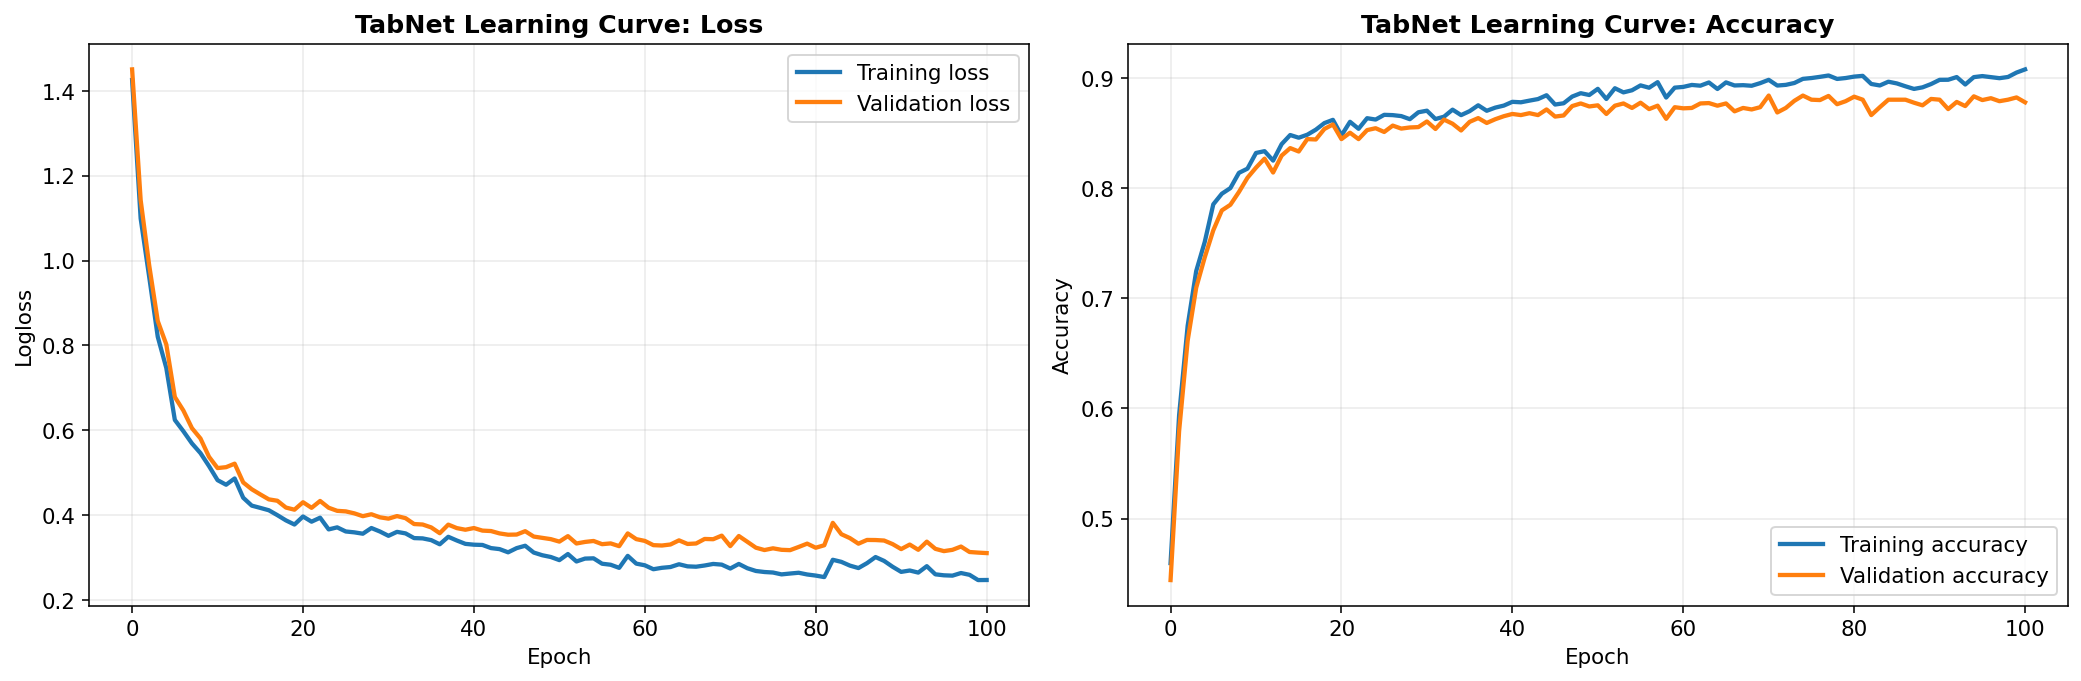


Test Accuracy: 0.8992

Classification Report:
              precision    recall  f1-score   support

         0.0     0.8667    0.8667    0.8667       105
         1.0     0.8889    0.9455    0.9163       110
         2.0     0.9279    0.9115    0.9196       113
         3.0     0.9333    0.9655    0.9492       116
         4.0     0.8372    0.8182    0.8276        88
         5.0     0.8851    0.8191    0.8508        94
         6.0     0.9352    0.9352    0.9352       108

    accuracy                         0.8992       734
   macro avg     0.8963    0.8945    0.8951       734
weighted avg     0.8989    0.8992    0.8987       734



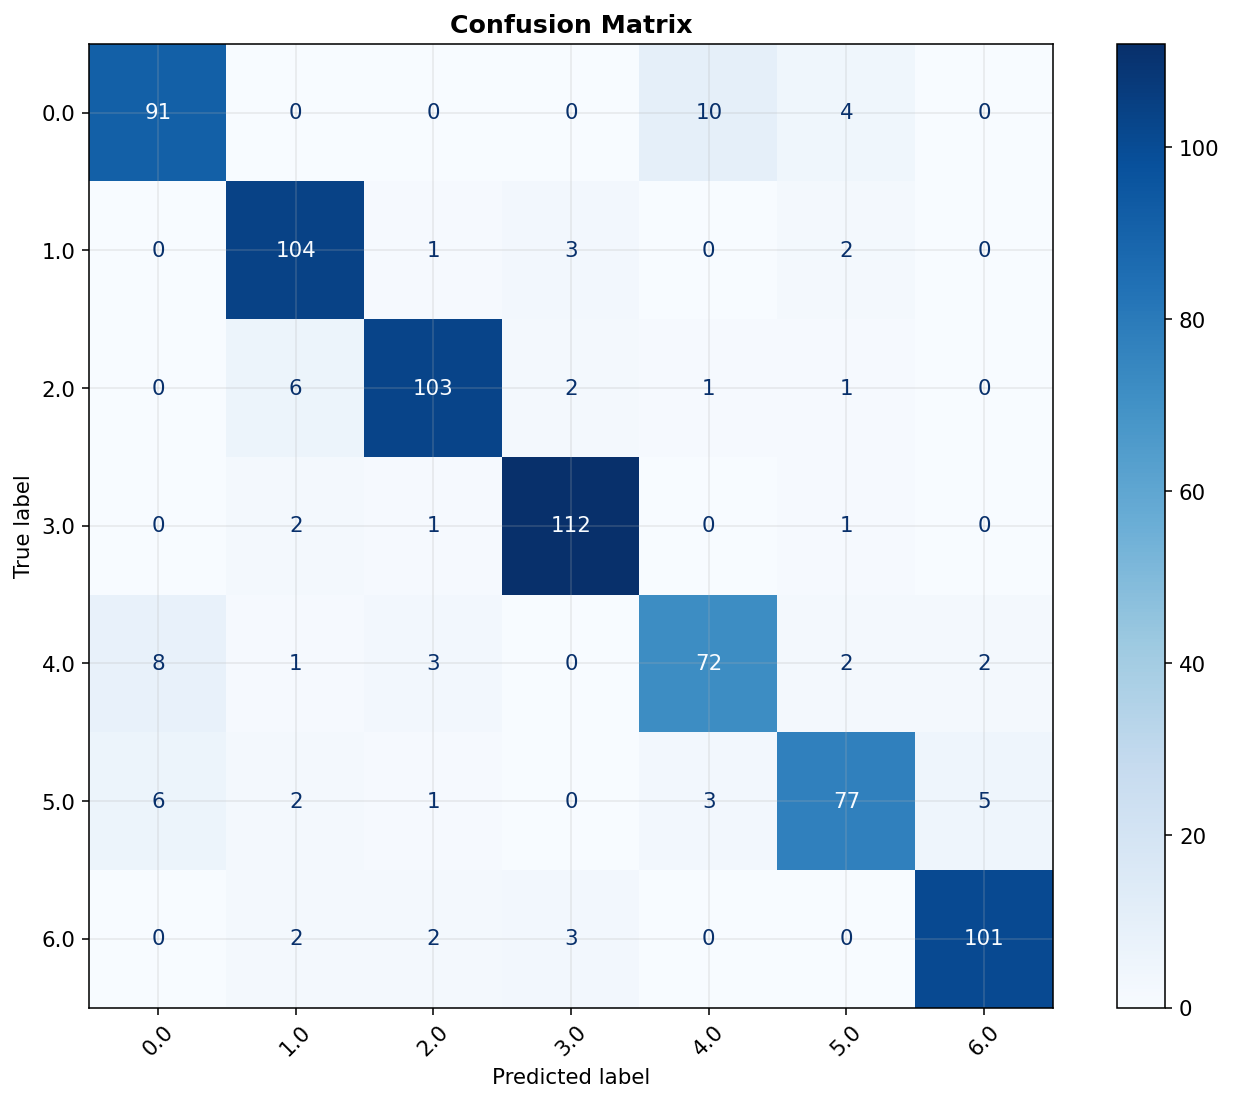

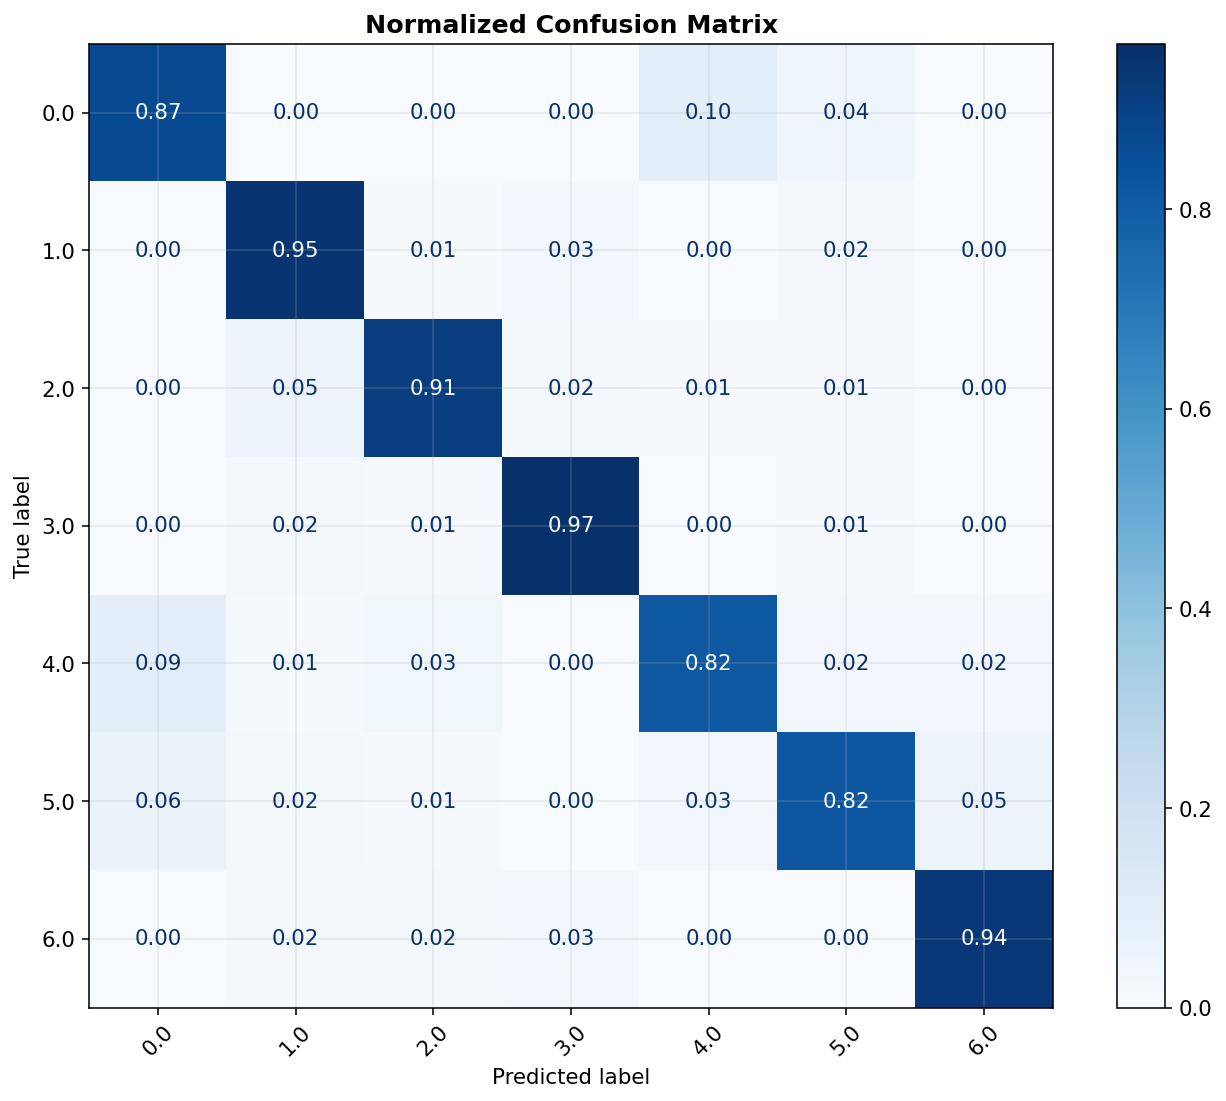

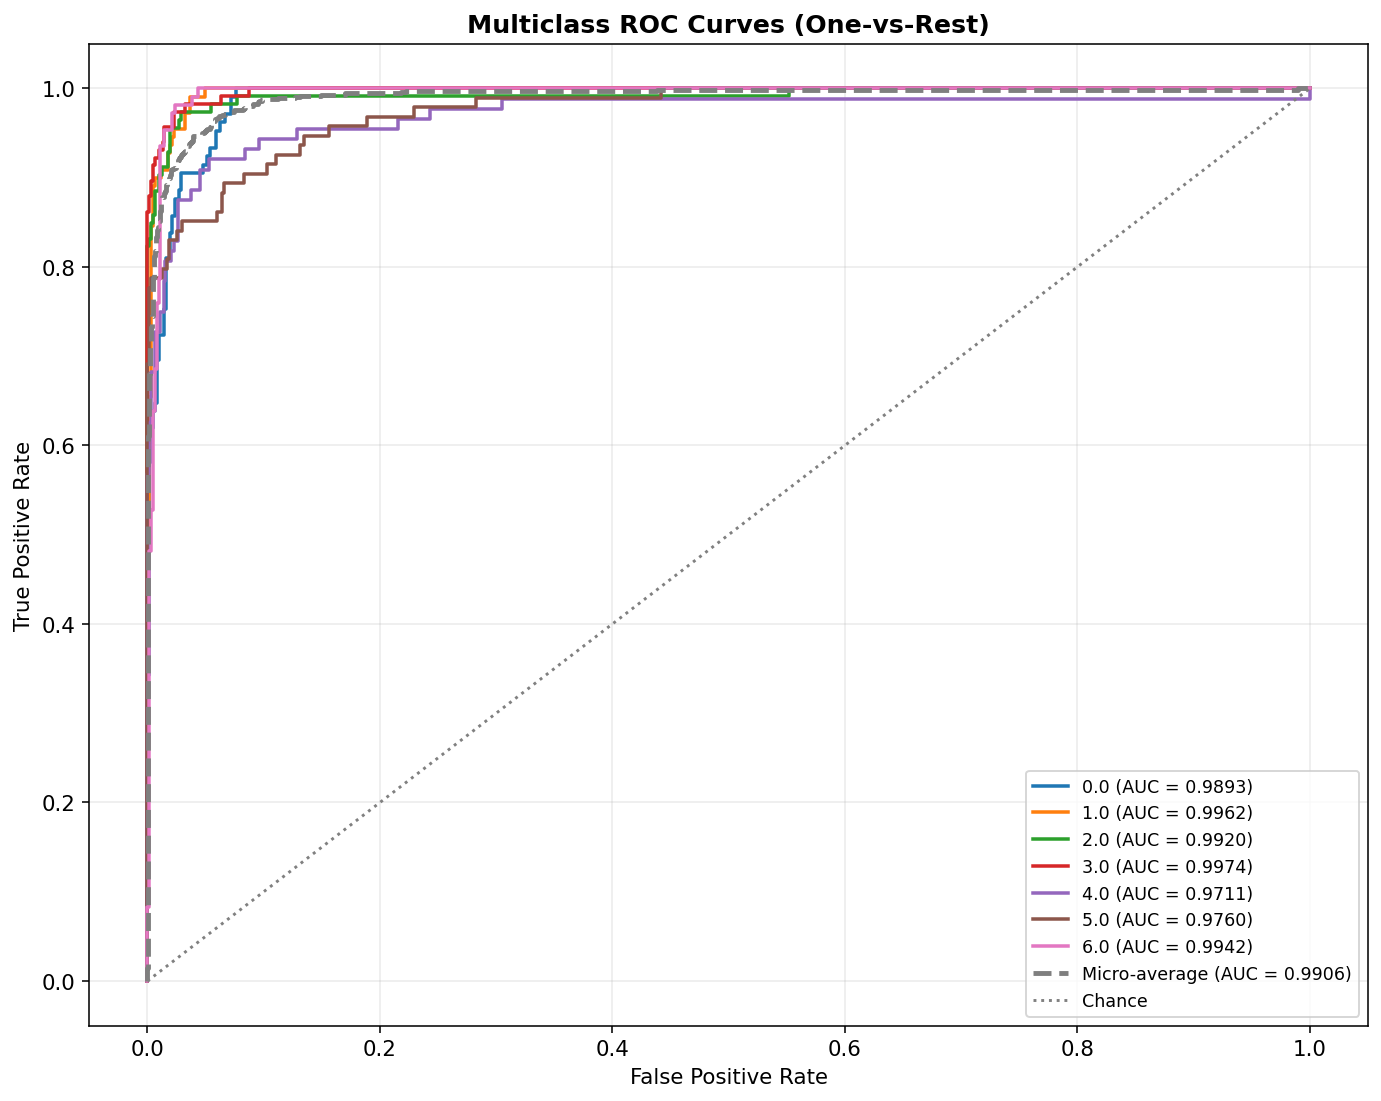


Macro ROC-AUC: 0.9880
Micro ROC-AUC: 0.9906

Per-class ROC-AUC:
  0.0: 0.9893
  1.0: 0.9962
  2.0: 0.9920
  3.0: 0.9974
  4.0: 0.9711
  5.0: 0.9760
  6.0: 0.9942


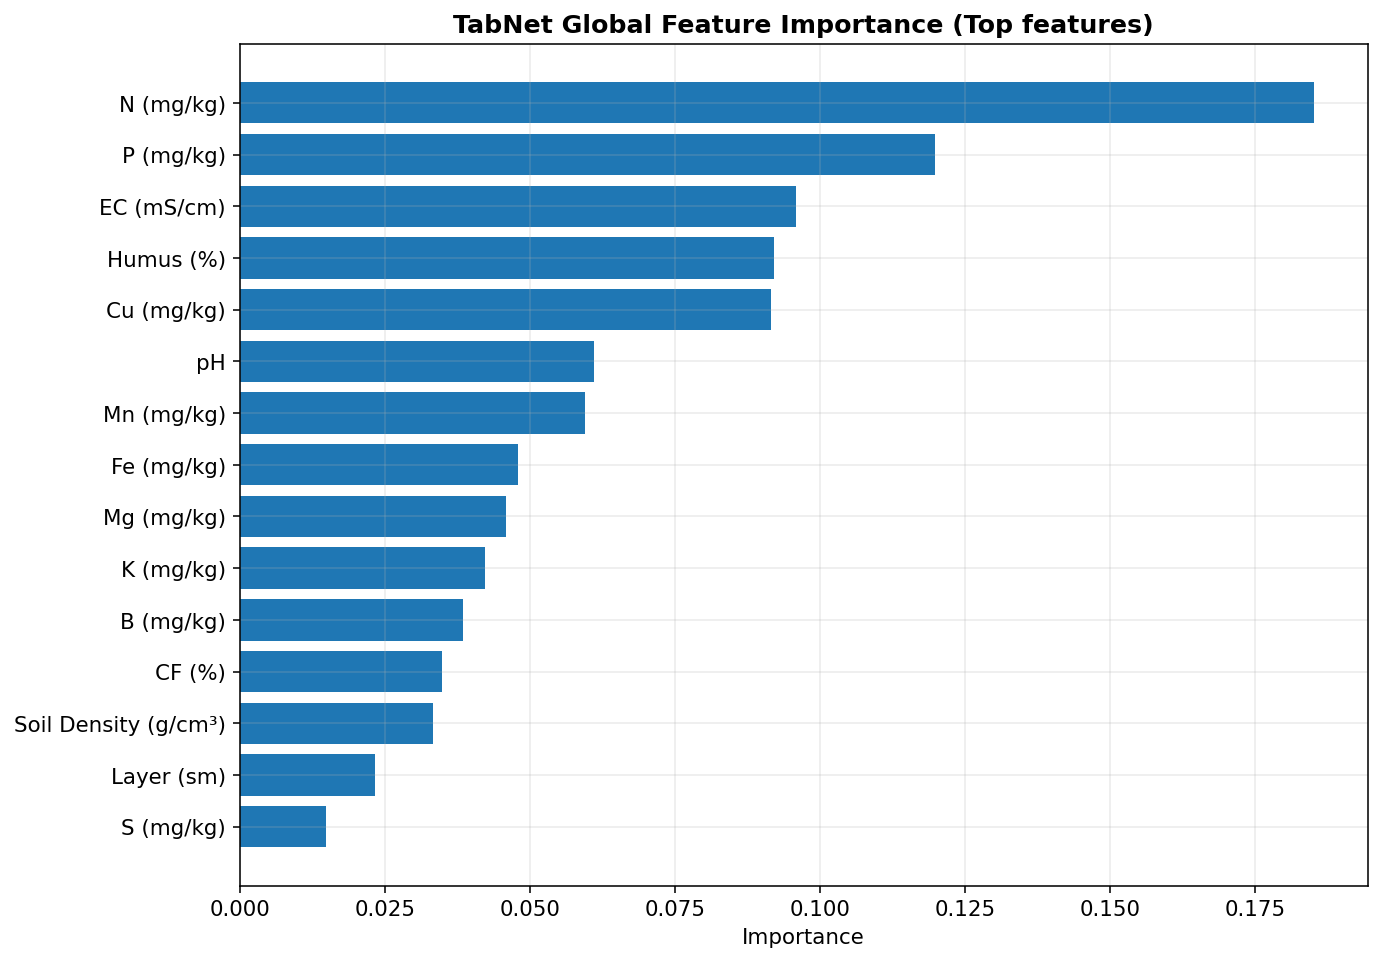


Top 15 feature importances:
             feature  importance
           N (mg/kg)    0.185113
           P (mg/kg)    0.119752
          EC (mS/cm)    0.095806
           Humus (%)    0.091997
          Cu (mg/kg)    0.091619
                  pH    0.061066
          Mn (mg/kg)    0.059441
          Fe (mg/kg)    0.047902
          Mg (mg/kg)    0.045842
           K (mg/kg)    0.042256
           B (mg/kg)    0.038571
              CF (%)    0.034954
Soil Density (g/cm³)    0.033371
          Layer (sm)    0.023312
           S (mg/kg)    0.014946


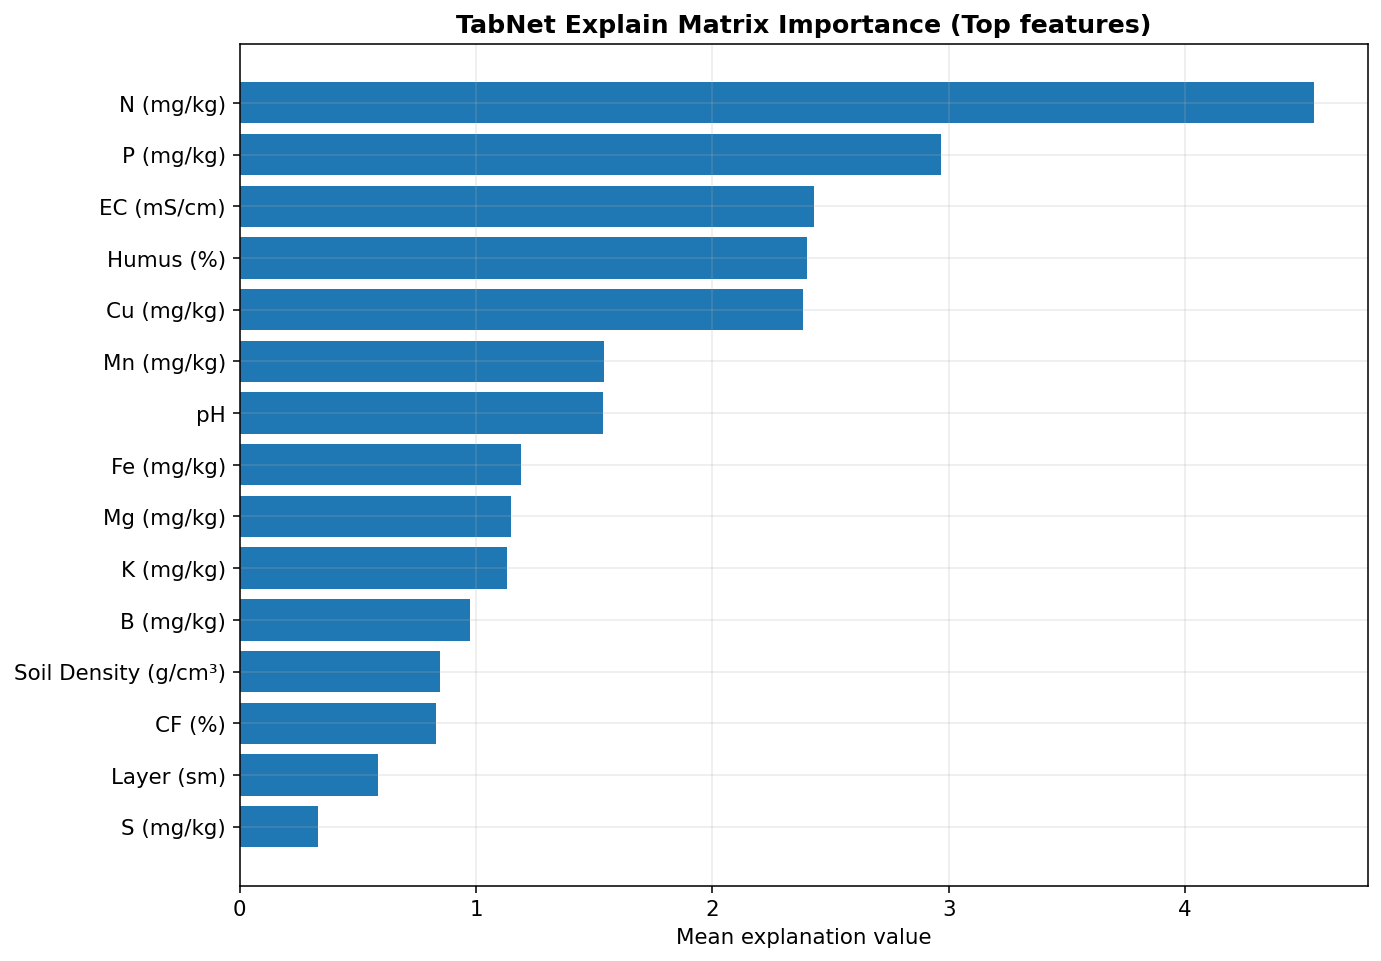


Top 15 explain-matrix features:
             feature  explain_importance
           N (mg/kg)            4.545249
           P (mg/kg)            2.966461
          EC (mS/cm)            2.431697
           Humus (%)            2.402242
          Cu (mg/kg)            2.383995
          Mn (mg/kg)            1.542853
                  pH            1.537082
          Fe (mg/kg)            1.190180
          Mg (mg/kg)            1.147739
           K (mg/kg)            1.132131
           B (mg/kg)            0.975271
Soil Density (g/cm³)            0.845771
              CF (%)            0.831653
          Layer (sm)            0.586759
           S (mg/kg)            0.330291


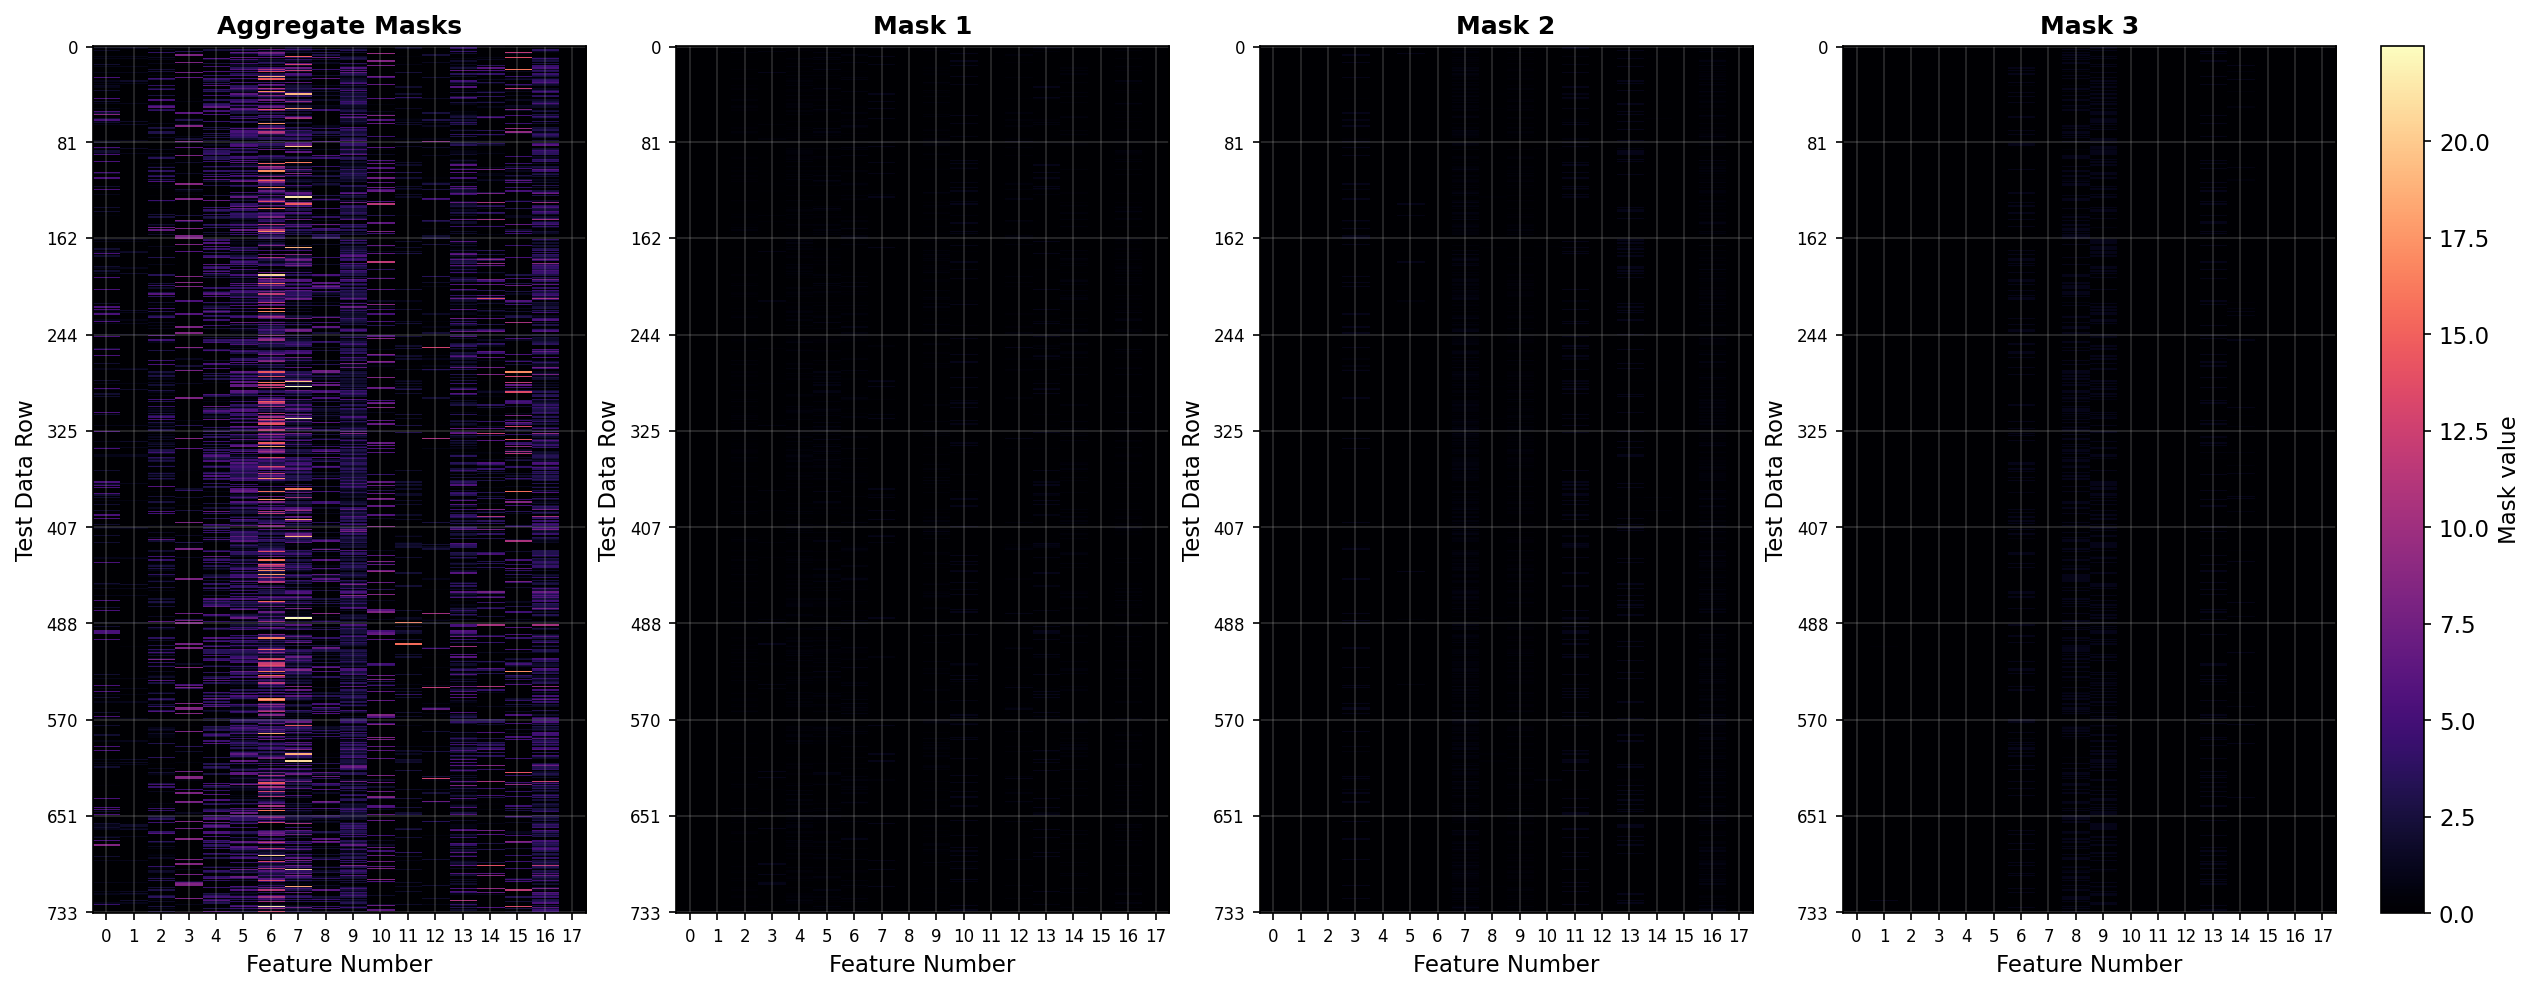


Hammasi tayyor. Natijalar 'tabnet_outputs' papkasiga saqlandi.


In [ ]:
# ============================================================
# TABNET CLASSIFICATION FOR CROP TARGET
# Epoch-wise metrics + Learning curves + ROC-AUC + CM + Masks
# ============================================================

# pip install pytorch-tabnet scikit-learn matplotlib pandas numpy torch

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from sklearn.model_selection import train_test_split, StratifiedKFold, learning_curve
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from sklearn.metrics import ConfusionMatrixDisplay

from pytorch_tabnet.tab_model import TabNetClassifier
from pytorch_tabnet.callbacks import Callback # Import the Callback base class

warnings.filterwarnings("ignore")

# -----------------------------
# 0) STYLE SETTINGS
# -----------------------------
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["font.size"] = 11

RANDOM_STATE = 42
TARGET_COL = "Crop"
DROP_COLS = ["Sample"]   # identifikator bo'lsa olib tashlash tavsiya qilinadi
OUTPUT_DIR = "tabnet_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ============================================================
# 1) DATAFRAME
# ============================================================
# df = pd.read_csv("your_dataset.csv")
# Sizda df allaqachon mavjud bo'lsa, yuqoridagi qatorni ishlatmaymiz.

assert TARGET_COL in df.columns, f"'{TARGET_COL}' ustuni topilmadi."

drop_cols_existing = [c for c in DROP_COLS if c in df.columns]
feature_cols = [c for c in df.columns if c not in drop_cols_existing + [TARGET_COL]]

X = df[feature_cols].copy()
y_raw = df[TARGET_COL].copy()

# Target encoding
le = LabelEncoder()
y = le.fit_transform(y_raw)

class_names = [str(c) for c in le.classes_]
n_classes = len(class_names)

print("Number of features:", len(feature_cols))
print("Number of classes:", n_classes)
print("Classes:", class_names)

# ============================================================
# 2) TRAIN / VALID / TEST SPLIT
# ============================================================
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.2,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

# Standardization
# TabNet raw numeric data bilan ishlaydi, lekin scaling ko'pincha barqarorlikni oshiradi.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# ============================================================
# 3) CUSTOM CALLBACK: EPOCH METRICS LOGGER
# ============================================================
# Bu callback har epochda loglarni saqlab boradi.
# Fit jarayonida eval_set = [(train), (valid)] berilsa,
# TabNet odatda train/valid metrikalarni birga hisoblaydi.
class EpochMetricsLogger(Callback):
    def __init__(self):
        self.history = []

    def on_epoch_end(self, epoch, logs=None):
        if logs is None:
            logs = {}
        row = {"epoch": epoch}
        row.update({k: float(v) if isinstance(v, (int, float, np.number)) else v for k, v in logs.items()})
        self.history.append(row)

# ============================================================
# 4) TABNET MODEL
# ============================================================
tabnet_params = dict(
    n_d=16,
    n_a=16,
    n_steps=5,
    gamma=1.5,
    n_independent=2,
    n_shared=2,
    lambda_sparse=1e-4,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2),
    mask_type="sparsemax",
    seed=RANDOM_STATE,
    device_name="auto",
    verbose=1
)

clf = TabNetClassifier(**tabnet_params)

metrics_logger = EpochMetricsLogger()

# ============================================================
# 5) FIT: TRAIN AND VALIDATION METRICS EACH EPOCH
# ============================================================
# eval_set ichiga train ham qo'shiladi, shunda:
# train_logloss, train_accuracy, valid_logloss, valid_accuracy
# har epochda monitoring qilinadi.
try:
    clf.fit(
        X_train=X_train,
        y_train=y_train,
        eval_set=[(X_train, y_train), (X_val, y_val)],
        eval_name=["train", "valid"],
        eval_metric=["logloss", "accuracy"],
        max_epochs=200,
        patience=30,
        batch_size=1024,
        virtual_batch_size=128,
        num_workers=0,
        drop_last=False,
        callbacks=[metrics_logger],
    )
except TypeError:
    # Ba'zi versiyalarda callbacks argumenti bo'lmasligi mumkin.
    # U holda faqat fitni bajaradi, keyin history ni boshqa yo'l bilan olamiz.
    clf.fit(
        X_train=X_train,
        y_train=y_train,
        eval_set=[(X_train, y_train), (X_val, y_val)],
        eval_name=["train", "valid"],
        eval_metric=["logloss", "accuracy"],
        max_epochs=200,
        patience=30,
        batch_size=1024,
        virtual_batch_size=128,
        num_workers=0,
        drop_last=False,
    )

# ============================================================
# 6) BUILD EPOCH HISTORY TABLE
# ============================================================
# Agar callback ishlagan bo'lsa:
history_df = pd.DataFrame(metrics_logger.history)

# Agar callback ishlamagan bo'lsa yoki bo'sh bo'lsa:
if history_df.empty:
    # TabNet modeli ichki tarixini olish uchun fallback
    # Versiyaga qarab clf.history dict yoki o'xshash struktura bo'lishi mumkin.
    try:
        history_df = pd.DataFrame(clf.history)
    except Exception as e:
        raise RuntimeError(
            "Epoch history topilmadi. Sizning pytorch-tabnet versiyangizda callback/history API boshqacha bo'lishi mumkin."
        ) from e

# Standart ustun nomlarini tekshirib olish
print("\nHistory columns:")
print(history_df.columns.tolist())

# ============================================================
# 7) MAP METRIC NAMES TO EXPECTED ONES
# ============================================================
# Kutubxona qaytargan ustunlar versiyaga qarab biroz farq qilishi mumkin.
# Quyidagi mapping common variantlarni moslaydi.
def find_col(cols, candidates):
    for c in candidates:
        if c in cols:
            return c
    return None

cols = history_df.columns.tolist()

train_loss_col = find_col(cols, ["train_logloss", "train_loss", "loss", "loss_train"])
valid_loss_col = find_col(cols, ["valid_logloss", "validation_logloss", "val_logloss", "val_loss"])
train_acc_col  = find_col(cols, ["train_accuracy", "train_acc", "accuracy_train"])
valid_acc_col  = find_col(cols, ["valid_accuracy", "validation_accuracy", "val_accuracy"])

# Agar callback logs ichida eval_name bo'yicha nomlar kelsa,
# ko'pincha train_logloss / valid_logloss shu ko'rinishda bo'ladi.
# Topilmasa, history_df.columns ni ko'rib moslab qo'ying.

# ============================================================
# 8) PLOT LEARNING CURVES: LOSS AND ACCURACY PER EPOCH
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 5), dpi=140)

# --- Loss curve ---
if train_loss_col is not None and valid_loss_col is not None:
    axes[0].plot(history_df["epoch"], history_df[train_loss_col], label="Training loss", linewidth=2.2)
    axes[0].plot(history_df["epoch"], history_df[valid_loss_col], label="Validation loss", linewidth=2.2)
    axes[0].set_title("TabNet Learning Curve: Loss", fontsize=13, weight="bold")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Logloss")
    axes[0].legend(frameon=True)
else:
    axes[0].text(0.5, 0.5, "Loss columns not found in history", ha="center", va="center")
    axes[0].set_axis_off()

# --- Accuracy curve ---
if train_acc_col is not None and valid_acc_col is not None:
    axes[1].plot(history_df["epoch"], history_df[train_acc_col], label="Training accuracy", linewidth=2.2)
    axes[1].plot(history_df["epoch"], history_df[valid_acc_col], label="Validation accuracy", linewidth=2.2)
    axes[1].set_title("TabNet Learning Curve: Accuracy", fontsize=13, weight="bold")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend(frameon=True)
else:
    axes[1].text(0.5, 0.5, "Accuracy columns not found in history", ha="center", va="center")
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()

# Agar xohlasangiz, to'liq epoch history ni saqlab qo'ying:
history_df.to_csv(os.path.join(OUTPUT_DIR, "epoch_history.csv"), index=False)

# ============================================================
# 9) TEST PREDICTION
# ============================================================
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)

test_acc = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy: {test_acc:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

# ============================================================
# 10) CONFUSION MATRIX (UNCHANGED STYLE)
# ============================================================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8), dpi=140)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues", values_format="d", xticks_rotation=45, ax=plt.gca())
plt.title("Confusion Matrix", fontsize=13, weight="bold")
plt.tight_layout()
plt.show()

# Normalized confusion matrix
cm_norm = confusion_matrix(y_test, y_pred, normalize="true")

plt.figure(figsize=(10, 8), dpi=140)
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=class_names)
disp_norm.plot(cmap="Blues", values_format=".2f", xticks_rotation=45, ax=plt.gca())
plt.title("Normalized Confusion Matrix", fontsize=13, weight="bold")
plt.tight_layout()
plt.show()

# ============================================================
# 11) ROC-AUC CURVES (UNCHANGED LOGIC)
# ============================================================
def plot_roc_curve_multiclass(y_true, y_score, class_names):
    n_classes = len(class_names)

    plt.figure(figsize=(10, 8), dpi=140)

    if n_classes == 2:
        fpr, tpr, _ = roc_curve(y_true, y_score[:, 1])
        auc_val = roc_auc_score(y_true, y_score[:, 1])
        plt.plot(fpr, tpr, linewidth=2.5, label=f"ROC curve (AUC = {auc_val:.4f})")
        plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1.5, label="Chance")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("ROC Curve", fontsize=13, weight="bold")
        plt.legend(loc="lower right")
        plt.tight_layout()
        plt.show()
        return

    # Multiclass OVR
    y_true_bin = label_binarize(y_true, classes=np.arange(n_classes))

    auc_per_class = {}
    for i, class_name in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_score[:, i])
        auc_i = roc_auc_score(y_true_bin[:, i], y_score[:, i])
        auc_per_class[class_name] = auc_i
        plt.plot(fpr, tpr, linewidth=1.8, label=f"{class_name} (AUC = {auc_i:.4f})")

    fpr_micro, tpr_micro, _ = roc_curve(y_true_bin.ravel(), y_score.ravel())
    auc_micro = roc_auc_score(y_true_bin, y_score, average="micro", multi_class="ovr")
    auc_macro = roc_auc_score(y_true_bin, y_score, average="macro", multi_class="ovr")

    plt.plot(fpr_micro, tpr_micro, linestyle="--", linewidth=2.5, label=f"Micro-average (AUC = {auc_micro:.4f})")
    plt.plot([0, 1], [0, 1], linestyle=":", linewidth=1.5, color="gray", label="Chance")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Multiclass ROC Curves (One-vs-Rest)", fontsize=13, weight="bold")
    plt.legend(fontsize=9, frameon=True)
    plt.tight_layout()
    plt.show()

    print(f"\nMacro ROC-AUC: {auc_macro:.4f}")
    print(f"Micro ROC-AUC: {auc_micro:.4f}")
    print("\nPer-class ROC-AUC:")
    for k, v in auc_per_class.items():
        print(f"  {k}: {v:.4f}")

plot_roc_curve_multiclass(y_test, y_proba, class_names)

# ============================================================
# 12) GLOBAL FEATURE IMPORTANCE
# ============================================================
# TabNet feature_importances_ global ahamiyatni beradi.
feature_importance = clf.feature_importances_

fi_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": feature_importance
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 7), dpi=140)
top_k = min(15, len(fi_df))
plt.barh(fi_df["feature"].head(top_k)[::-1], fi_df["importance"].head(top_k)[::-1])
plt.title("TabNet Global Feature Importance (Top features)", fontsize=13, weight="bold")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print("\nTop 15 feature importances:")
print(fi_df.head(15).to_string(index=False))

fi_df.to_csv(os.path.join(OUTPUT_DIR, "feature_importance_tabnet.csv"), index=False)

# ============================================================
# 13) TABNET EXPLAIN MATRIX AND MASKS
# ============================================================
# explain_matrix: global explanation
# masks: decision step bo'yicha masklar
explain_matrix, masks = clf.explain(X_test)

# Global explain importance
explain_importance = explain_matrix.mean(axis=0)
exp_df = pd.DataFrame({
    "feature": feature_cols,
    "explain_importance": explain_importance
}).sort_values("explain_importance", ascending=False)

plt.figure(figsize=(10, 7), dpi=140)
plt.barh(exp_df["feature"].head(top_k)[::-1], exp_df["explain_importance"].head(top_k)[::-1])
plt.title("TabNet Explain Matrix Importance (Top features)", fontsize=13, weight="bold")
plt.xlabel("Mean explanation value")
plt.tight_layout()
plt.show()

print("\nTop 15 explain-matrix features:")
print(exp_df.head(15).to_string(index=False))

exp_df.to_csv(os.path.join(OUTPUT_DIR, "explain_importance_tabnet.csv"), index=False)

# ============================================================
# 14) MASK HEATMAPS: AGGREGATE + STEP-WISE (LIKE YOUR SAMPLE)
# ============================================================
# Namuna kabi:
# Aggregate Masks | Mask 1 | Mask 2 | Mask 3
#
# Har bir heatmap:
# rows = test sample index
# cols = feature index
#
# Agar masklar soni 3 dan ko'p bo'lsa, birinchi 3 tasini chizamiz.
# Xohlasangiz, hammasini chizadigan variantni ham qo'ysa bo'ladi.
def sort_key(k):
    try:
        return int(k)
    except Exception:
        return str(k)

mask_items = sorted(masks.items(), key=lambda kv: sort_key(kv[0]))

# Mask arrays ready
# explain_matrix shape usually: (n_samples, n_features)
# masks each step shape: (n_samples, n_features)
heatmaps = [("Aggregate Masks", np.asarray(explain_matrix))]

for i, (step_key, step_mask) in enumerate(mask_items[:3], start=1):
    heatmaps.append((f"Mask {i}", np.asarray(step_mask)))

# Determine global color scale for consistent scientific comparison
all_vals = np.concatenate([h[1].ravel() for h in heatmaps])
vmin = np.nanmin(all_vals)
vmax = np.nanmax(all_vals)

n_plots = len(heatmaps)
fig, axes = plt.subplots(1, n_plots, figsize=(4.2 * n_plots, 6.5), dpi=150, constrained_layout=True)

if n_plots == 1:
    axes = [axes]

for ax, (title, mat) in zip(axes, heatmaps):
    im = ax.imshow(mat, aspect="auto", interpolation="nearest", cmap="magma", vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=12, weight="bold")
    ax.set_xlabel("Feature Number")
    ax.set_ylabel("Test Data Row")

    # x-axis feature indexes
    ax.set_xticks(np.arange(len(feature_cols)))
    ax.set_xticklabels(np.arange(len(feature_cols)), fontsize=8)

    # y-axis sample indexes: agar test sample ko'p bo'lsa, hammasini emas, bir qismini ko'rsatamiz
    n_rows = mat.shape[0]
    if n_rows <= 12:
        y_ticks = np.arange(n_rows)
    else:
        y_ticks = np.linspace(0, n_rows - 1, 10, dtype=int)
    ax.set_yticks(y_ticks)
    ax.set_yticklabels(y_ticks, fontsize=8)

# Bitta shared colorbar
cbar = fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02)
cbar.set_label("Mask value", rotation=90)

plt.show()

# ============================================================
# 15) OPTIONAL: SAVE FINAL PREDICTIONS
# ============================================================
pred_df = pd.DataFrame({
    "y_true": le.inverse_transform(y_test),
    "y_pred": le.inverse_transform(y_pred)
})

if y_proba.shape[1] == len(class_names):
    for idx, cname in enumerate(class_names):
        pred_df[f"proba_{cname}"] = y_proba[:, idx]

pred_df.to_csv(os.path.join(OUTPUT_DIR, "test_predictions.csv"), index=False)

print(f"\nHammasi tayyor. Natijalar '{OUTPUT_DIR}' papkasiga saqlandi.")



Top features:
                 feature  importance  importance_norm
0              N (mg/kg)    0.185113         1.000000
1              P (mg/kg)    0.119752         0.646912
2             EC (mS/cm)    0.095806         0.517547
3              Humus (%)    0.091997         0.496971
4             Cu (mg/kg)    0.091619         0.494932
5                     pH    0.061066         0.329879
6             Mn (mg/kg)    0.059441         0.321101
7             Fe (mg/kg)    0.047902         0.258762
8             Mg (mg/kg)    0.045842         0.247632
9              K (mg/kg)    0.042256         0.228264
10             B (mg/kg)    0.038571         0.208356
11                CF (%)    0.034954         0.188815
12  Soil Density (g/cm³)    0.033371         0.180263
13            Layer (sm)    0.023312         0.125922
14             S (mg/kg)    0.014946         0.080730


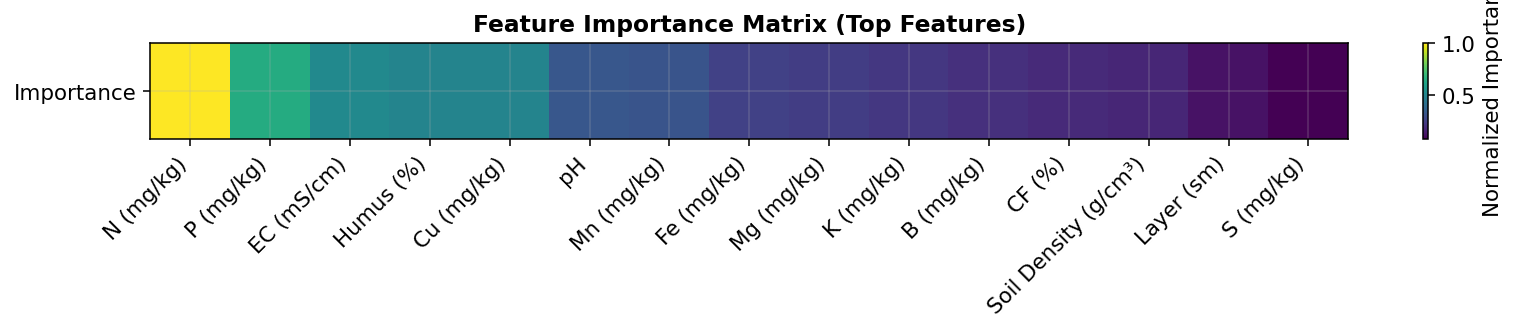

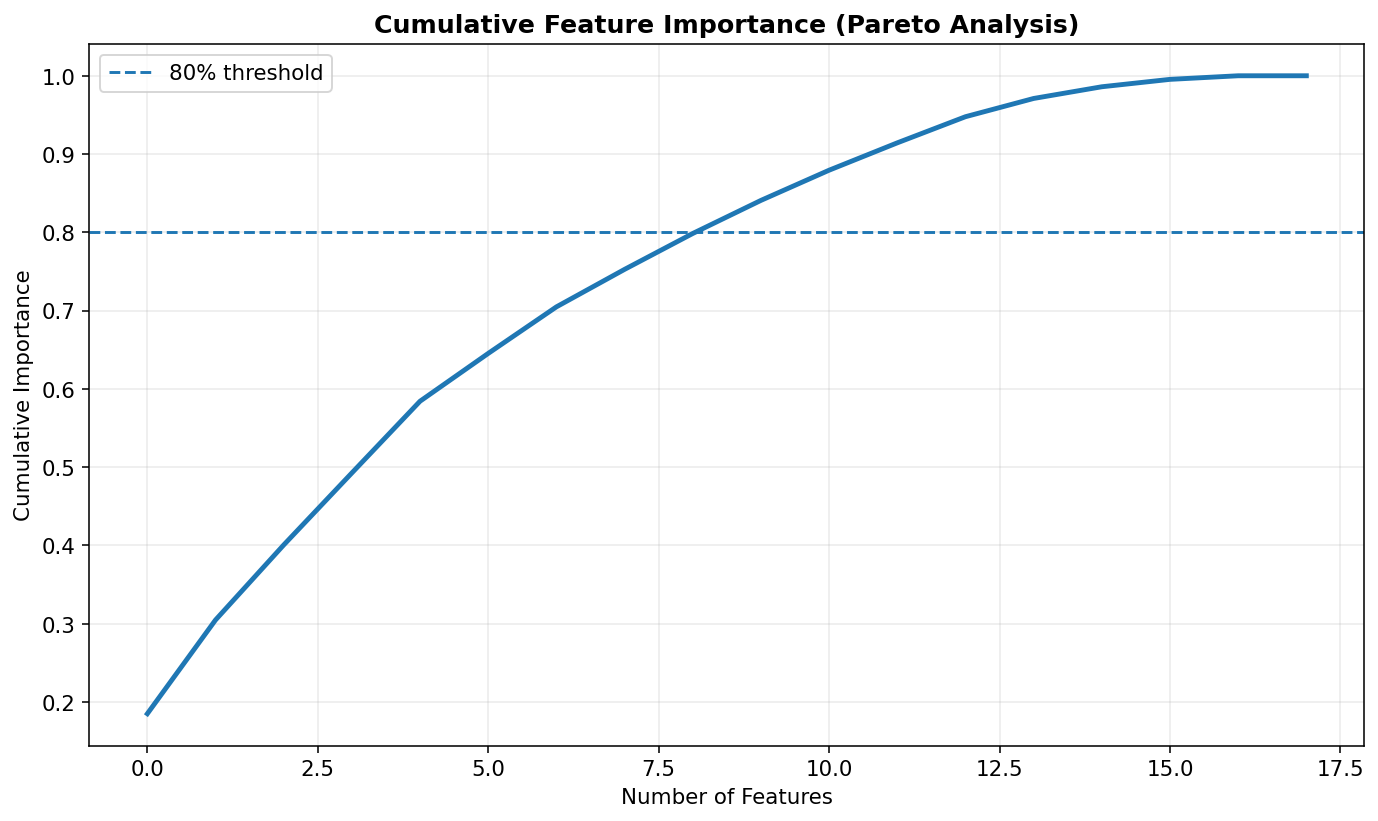

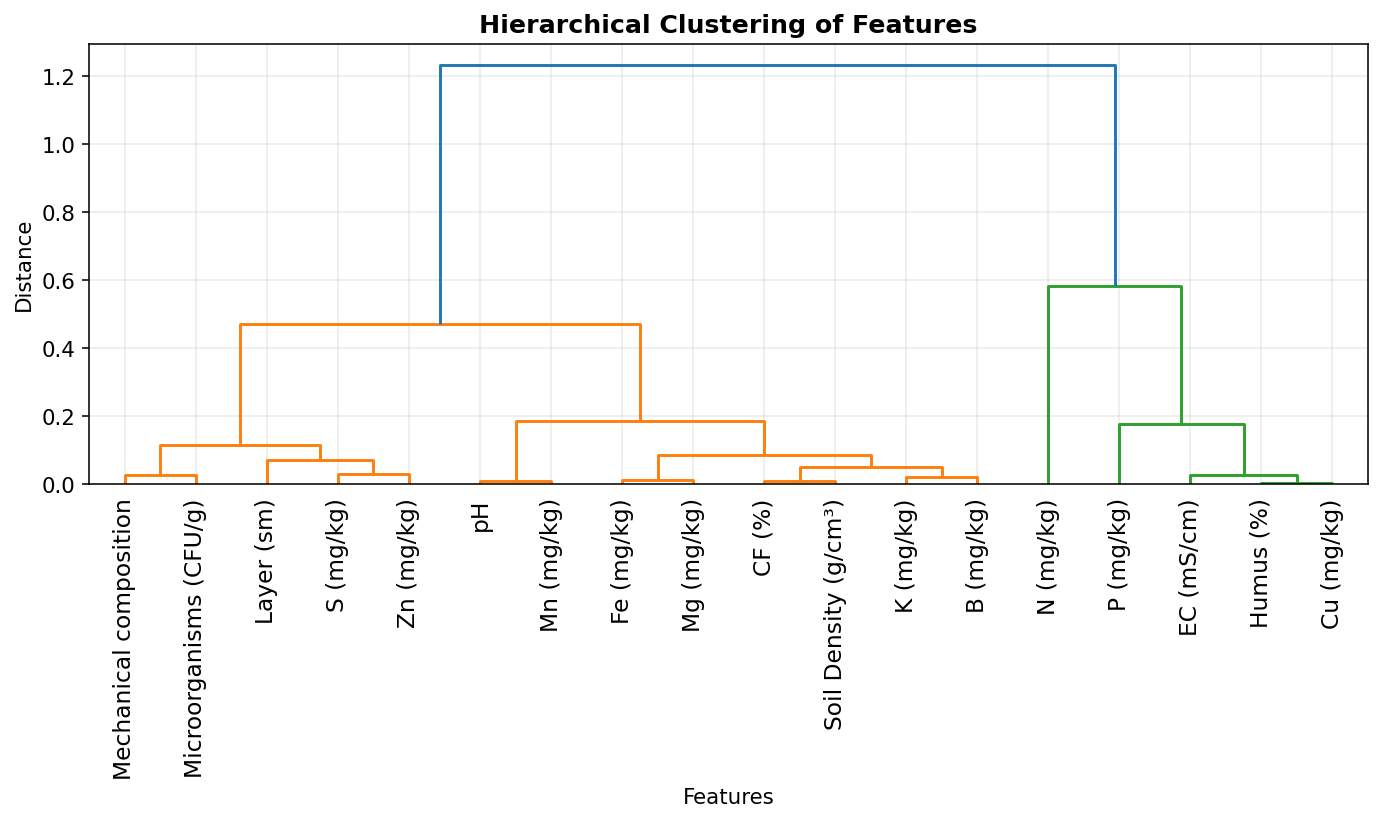

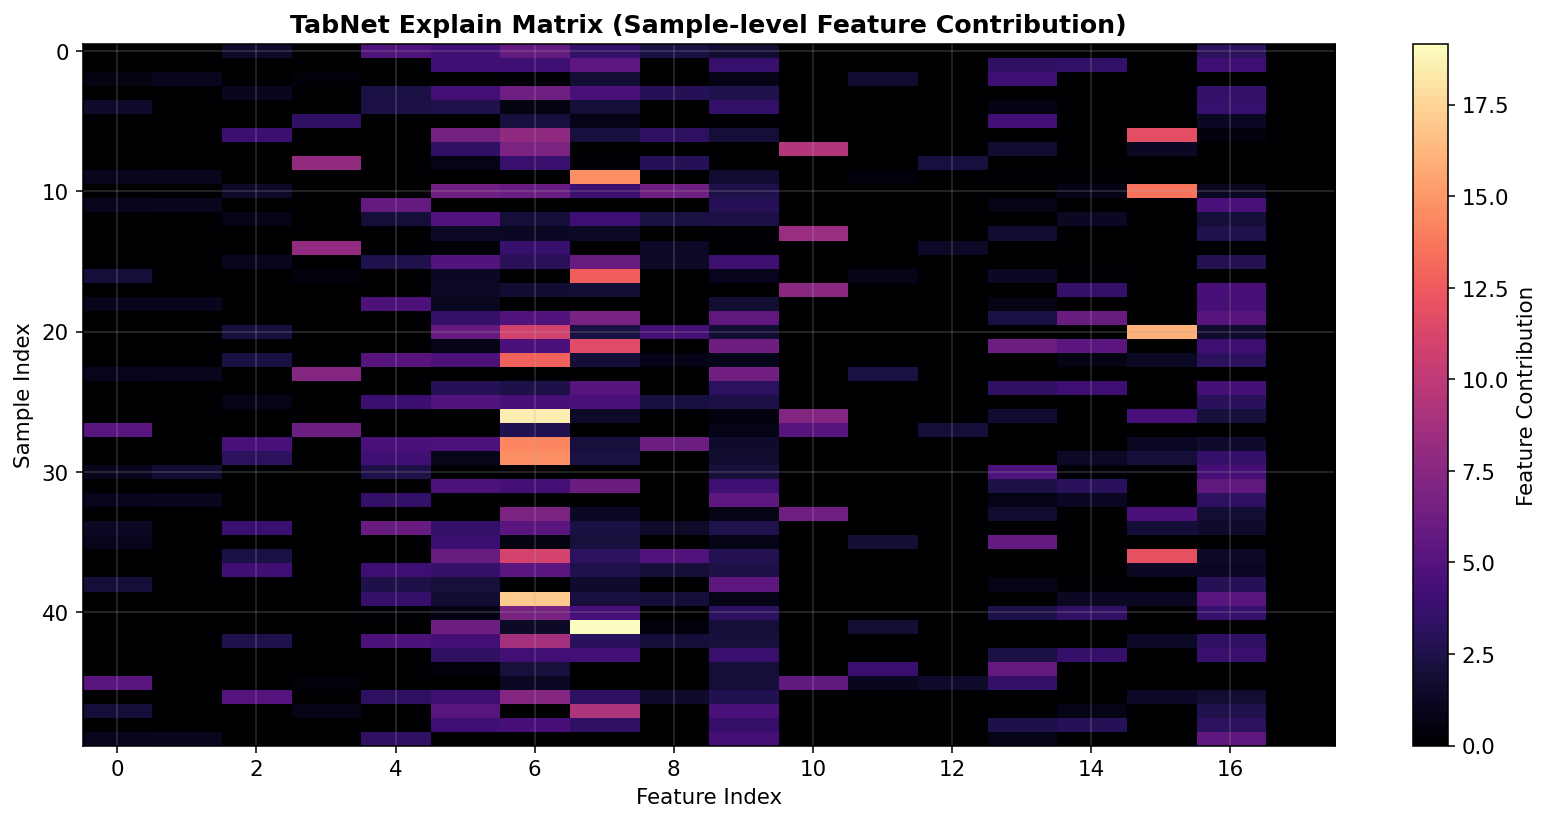

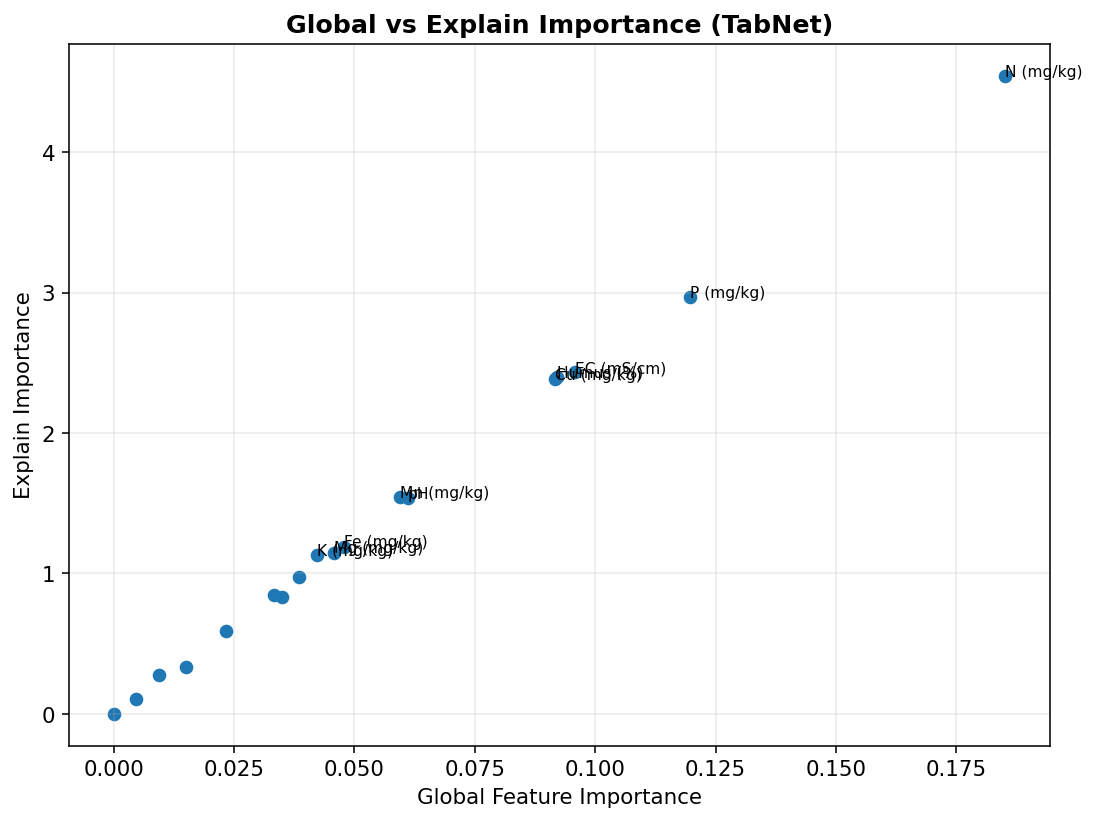

In [ ]:
# ============================================================
# ADVANCED FEATURE IMPORTANCE VISUALIZATION (POST-TABNET)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.preprocessing import MinMaxScaler

# ============================================================
# 1) GLOBAL FEATURE IMPORTANCE (TABNET)
# ============================================================
feature_importance = clf.feature_importances_

fi_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": feature_importance
}).sort_values("importance", ascending=False).reset_index(drop=True)

# Normalize for visualization
scaler = MinMaxScaler()
fi_df["importance_norm"] = scaler.fit_transform(fi_df[["importance"]])

print("\nTop features:")
print(fi_df.head(15))

# ============================================================
# 2) IMPORTANCE MATRIX HEATMAP (TOP-K FEATURES)
# ============================================================
TOP_K = 15
top_features = fi_df.head(TOP_K)["feature"].values
top_values = fi_df.head(TOP_K)["importance_norm"].values.reshape(1, -1)

plt.figure(figsize=(12, 2.5), dpi=140)
plt.imshow(top_values, aspect="auto", cmap="viridis")

plt.xticks(ticks=np.arange(TOP_K), labels=top_features, rotation=45, ha="right")
plt.yticks([0], ["Importance"])
plt.title("Feature Importance Matrix (Top Features)", fontsize=12, weight="bold")

cbar = plt.colorbar()
cbar.set_label("Normalized Importance")

plt.tight_layout()
plt.show()

# ============================================================
# 3) CUMULATIVE IMPORTANCE (PARETO ANALYSIS)
# ============================================================
fi_df["cumulative_importance"] = fi_df["importance"].cumsum()
fi_df["cumulative_importance"] /= fi_df["importance"].sum()

plt.figure(figsize=(10, 6), dpi=140)

plt.plot(fi_df["cumulative_importance"].values, linewidth=2.5)
plt.axhline(0.8, linestyle="--", label="80% threshold")

plt.xlabel("Number of Features")
plt.ylabel("Cumulative Importance")
plt.title("Cumulative Feature Importance (Pareto Analysis)", fontsize=13, weight="bold")
plt.legend()

plt.tight_layout()
plt.show()

# ============================================================
# 4) HIERARCHICAL CLUSTERED HEATMAP (VERY SCIENTIFIC)
# ============================================================
# Feature importance asosida featurelarni guruhlash
# (ilmiy maqolalarda juda yaxshi ko'rinadi)

# reshape for clustering
data_for_cluster = fi_df[["importance_norm"]].values

# linkage
Z = linkage(data_for_cluster, method="ward")

plt.figure(figsize=(10, 6), dpi=140)
dendrogram(Z, labels=fi_df["feature"].values, leaf_rotation=90)

plt.title("Hierarchical Clustering of Features", fontsize=13, weight="bold")
plt.xlabel("Features")
plt.ylabel("Distance")

plt.tight_layout()
plt.show()

# ============================================================
# 5) TABNET EXPLAIN MATRIX (GLOBAL HEATMAP)
# ============================================================
explain_matrix, masks = clf.explain(X_test)

# Sample subset for visualization (katta dataset bo'lsa)
n_samples_show = min(50, explain_matrix.shape[0])
exp_subset = explain_matrix[:n_samples_show, :]

plt.figure(figsize=(12, 6), dpi=140)
plt.imshow(exp_subset, aspect="auto", cmap="magma")

plt.colorbar(label="Feature Contribution")
plt.xlabel("Feature Index")
plt.ylabel("Sample Index")
plt.title("TabNet Explain Matrix (Sample-level Feature Contribution)", fontsize=13, weight="bold")

plt.tight_layout()
plt.show()

# ============================================================
# 6) FEATURE vs EXPLAIN IMPORTANCE COMPARISON
# ============================================================
exp_importance = explain_matrix.mean(axis=0)

compare_df = pd.DataFrame({
    "feature": feature_cols,
    "global_importance": feature_importance,
    "explain_importance": exp_importance
})

compare_df = compare_df.sort_values("global_importance", ascending=False)

# scatter plot (ilmiy juda yaxshi ko'rinadi)
plt.figure(figsize=(8, 6), dpi=140)

plt.scatter(compare_df["global_importance"], compare_df["explain_importance"])

for i in range(min(10, len(compare_df))):
    plt.text(
        compare_df["global_importance"].iloc[i],
        compare_df["explain_importance"].iloc[i],
        compare_df["feature"].iloc[i],
        fontsize=8
    )

plt.xlabel("Global Feature Importance")
plt.ylabel("Explain Importance")
plt.title("Global vs Explain Importance (TabNet)", fontsize=13, weight="bold")

plt.tight_layout()
plt.show()

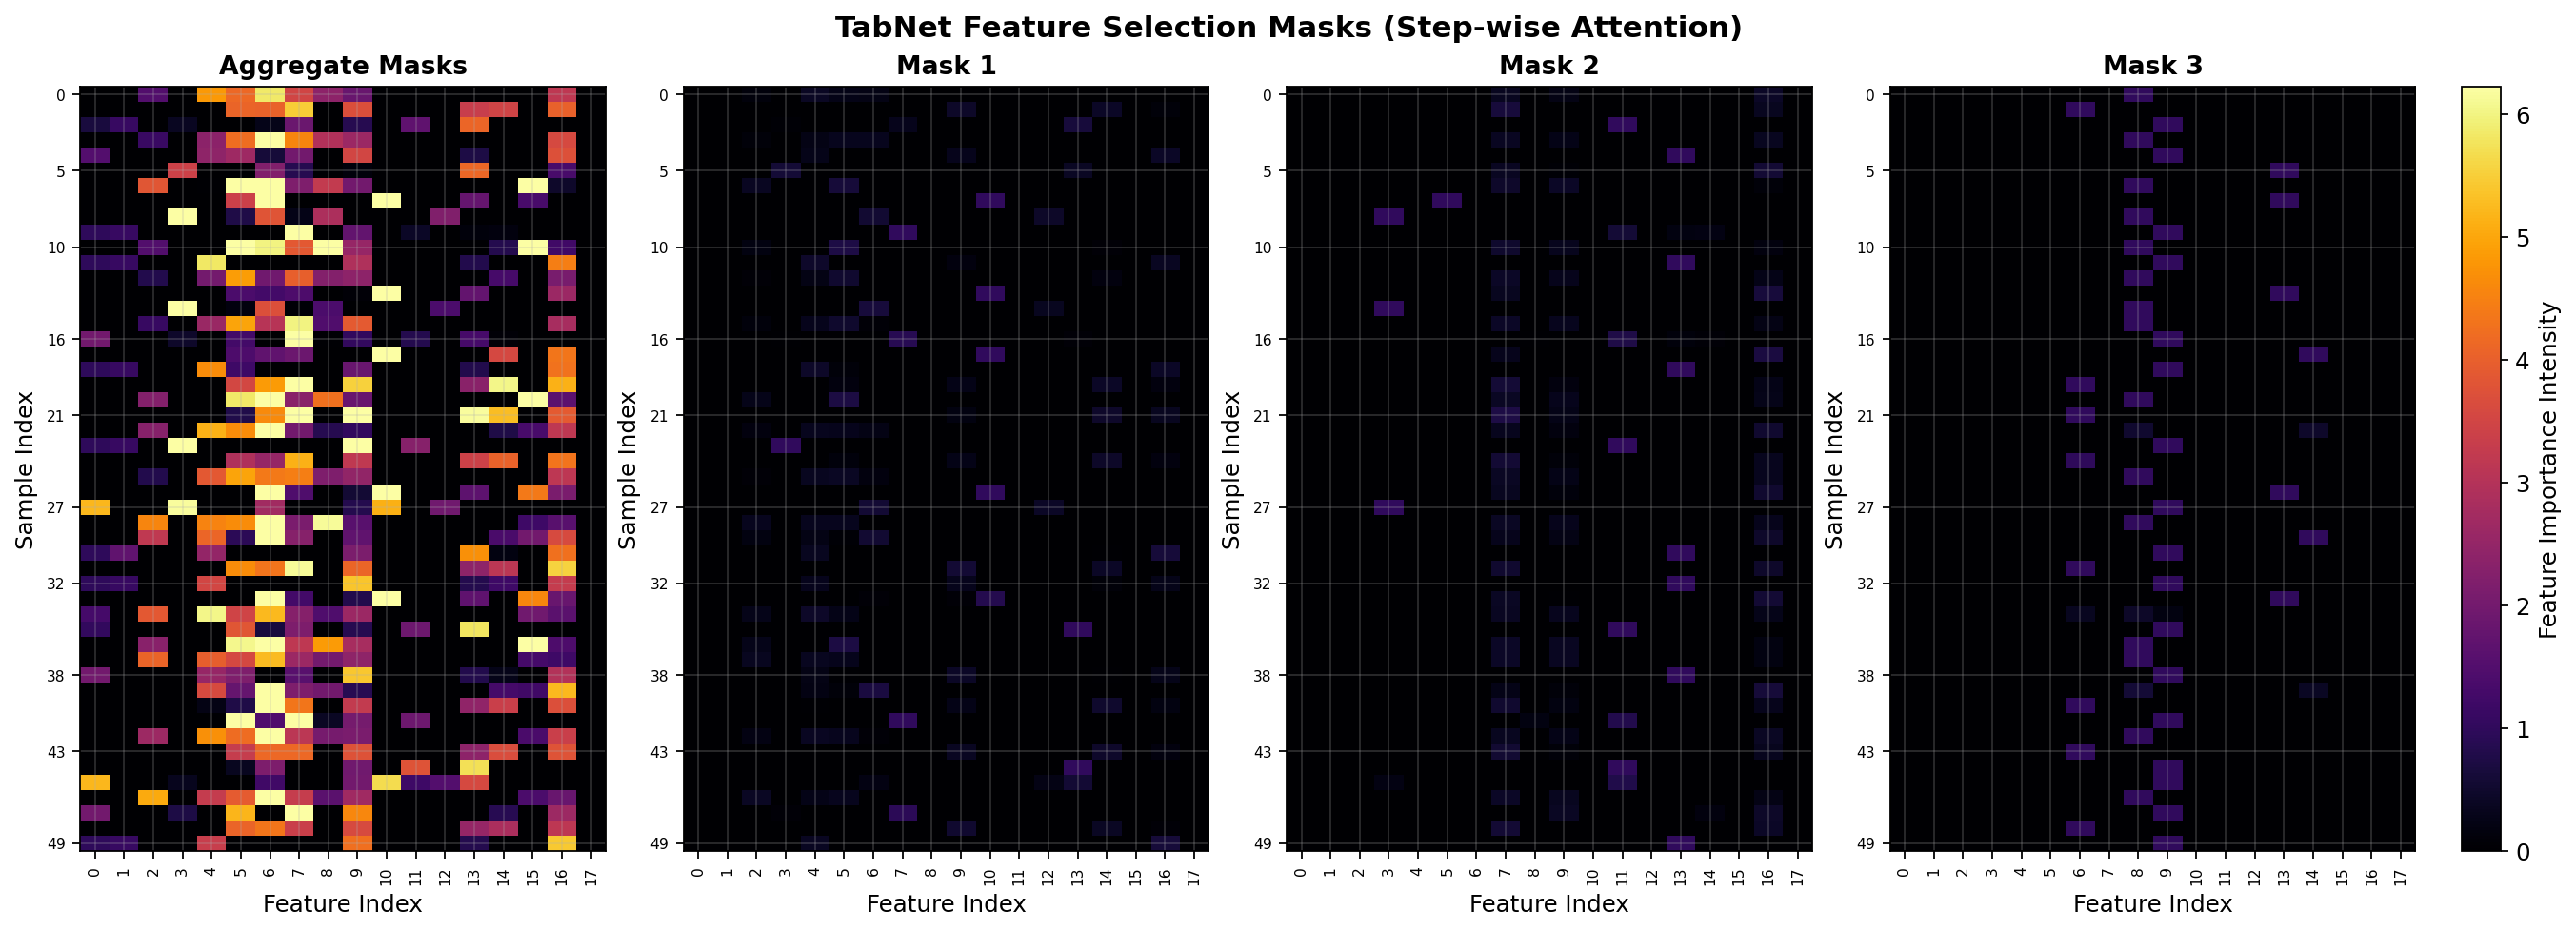

In [ ]:
# ============================================================
# TABNET MASK VISUALIZATION (n_steps = 5)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# Explain olish
explain_matrix, masks = clf.explain(X_test)

# --------- SAMPLE SIZE (ko‘rinish uchun qisqartiramiz) ----------
n_samples_show = min(50, explain_matrix.shape[0])

aggregate_mask = np.asarray(explain_matrix[:n_samples_show, :])

# Masklarni tartiblash
def sort_key(k):
    try:
        return int(k)
    except:
        return str(k)

mask_items = sorted(masks.items(), key=lambda kv: sort_key(kv[0]))

# Faqat 5 ta step olish
selected_masks = mask_items[:3]

# --------- HEATMAP DATA ----------
heatmaps = [("Aggregate Masks", aggregate_mask)]

for i, (step_key, step_mask) in enumerate(selected_masks, start=1):
    heatmaps.append((f"Mask {i}", np.asarray(step_mask[:n_samples_show, :])))

# --------- GLOBAL COLOR SCALE (ilmiy jihatdan muhim) ----------
all_values = np.concatenate([h[1].ravel() for h in heatmaps])
vmin = np.percentile(all_values, 1)   # outlierlarni kamaytirish
vmax = np.percentile(all_values, 99)

# --------- PLOT ----------
n_plots = len(heatmaps)

fig, axes = plt.subplots(
    1, n_plots,
    figsize=(4.2 * n_plots, 6),
    dpi=160,
    constrained_layout=True
)

if n_plots == 1:
    axes = [axes]

# 🔥 Eng yaxshi ilmiy colormap (yuqori kontrast)
cmap = "inferno"   # alternativ: "magma", "plasma"

for ax, (title, mat) in zip(axes, heatmaps):
    im = ax.imshow(
        mat,
        aspect="auto",
        interpolation="nearest",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax
    )

    ax.set_title(title, fontsize=12, weight="bold")
    ax.set_xlabel("Feature Index")
    ax.set_ylabel("Sample Index")

    # Feature indexlar
    ax.set_xticks(np.arange(len(feature_cols)))
    ax.set_xticklabels(np.arange(len(feature_cols)), fontsize=7, rotation=90)

    # Sample indexlar
    n_rows = mat.shape[0]
    if n_rows <= 15:
        yticks = np.arange(n_rows)
    else:
        yticks = np.linspace(0, n_rows - 1, 10, dtype=int)

    ax.set_yticks(yticks)
    ax.set_yticklabels(yticks, fontsize=7)

# --------- SHARED COLORBAR ----------
cbar = fig.colorbar(
    im,
    ax=axes,
    fraction=0.02,
    pad=0.02
)
cbar.set_label("Feature Importance Intensity", fontsize=11)

plt.suptitle(
    "TabNet Feature Selection Masks (Step-wise Attention)",
    fontsize=14,
    weight="bold"
)

plt.show()

In [ ]:
crop_mapping = dict(zip(encoder.categories_[0], range(len(encoder.categories_[0]))))

# reverse mapping
reverse_mapping = {v: k for k, v in crop_mapping.items()}

In [ ]:
df.head()

,Sample,Layer (sm),Mechanical composition,CF (%),Soil Density (g/cm³),pH,EC (mS/cm),N (mg/kg),P (mg/kg),K (mg/kg),Humus (%),Mg (mg/kg),S (mg/kg),Zn (mg/kg),Mn (mg/kg),B (mg/kg),Fe (mg/kg),Cu (mg/kg),Microorganisms (CFU/g),Crop
0,2963.0,2.0,2.0,25.712807,1.457113,7.937305,2.314010,14.730419,8.522521,149.053614,0.608170,191.606107,14.281694,57.778321,87.646882,0.420984,96.509662,12.516341,1267278.0,6.0
1,387.0,2.0,2.0,25.433538,1.464649,6.246307,1.821689,82.620026,69.432481,253.167410,2.593501,111.327086,20.601440,39.687666,46.070441,1.540358,147.093984,11.615279,77076271.0,2.0
2,2063.0,1.0,0.0,23.689499,0.122849,8.289166,2.013845,14.648041,7.270005,115.110419,0.465548,155.009343,9.057294,21.729273,119.843093,1.064296,136.168008,15.113455,418065.0,0.0
3,310.0,0.0,0.0,31.897131,0.864834,7.040737,1.658389,162.834909,73.458159,252.186845,2.475862,191.849055,29.624305,42.607224,118.275093,1.651026,260.485571,21.478858,56876960.0,2.0
4,311.0,1.0,3.0,26.628374,0.631225,7.323268,1.518346,120.695096,63.034031,214.797463,2.329035,121.493596,32.524197,59.549807,95.159108,1.176211,242.888489,18.562968,11331527.0,5.0



=== Sample 1 ===
Predicted Crop: 1.0
Confidence: 56.28%

=== Sample 2 ===
Predicted Crop: 1.0
Confidence: 78.33%

=== Sample 3 ===
Predicted Crop: 4.0
Confidence: 25.98%

=== Sample 4 ===
Predicted Crop: 2.0
Confidence: 80.83%

=== Sample 5 ===
Predicted Crop: 1.0
Confidence: 85.28%


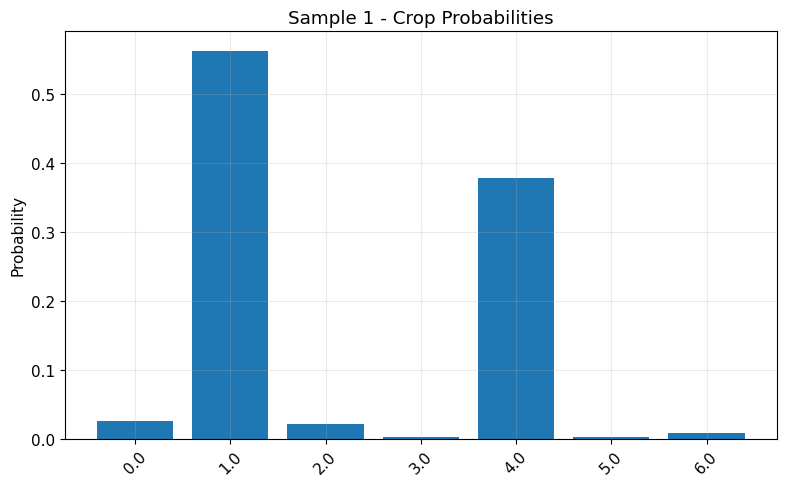

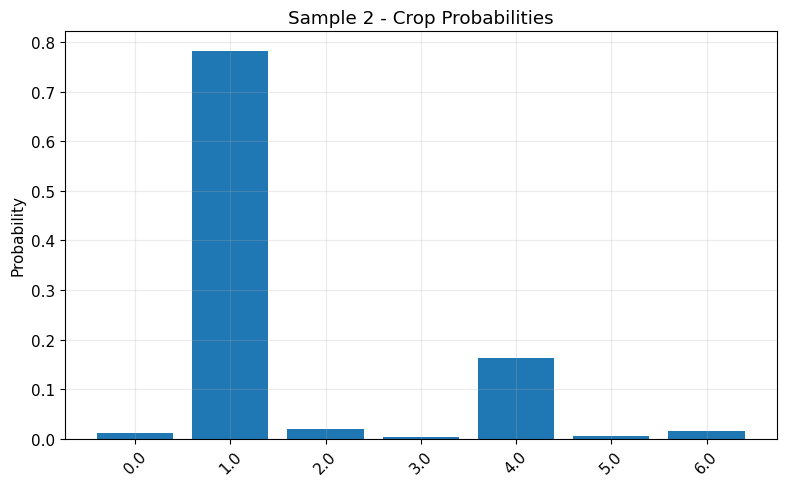

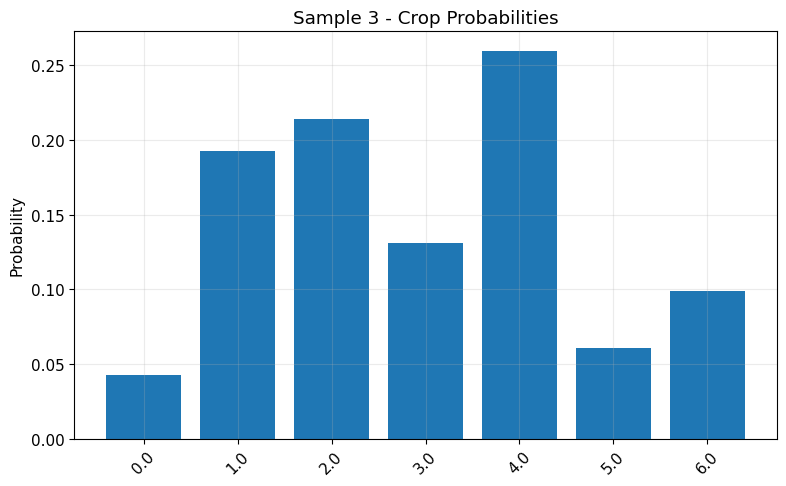

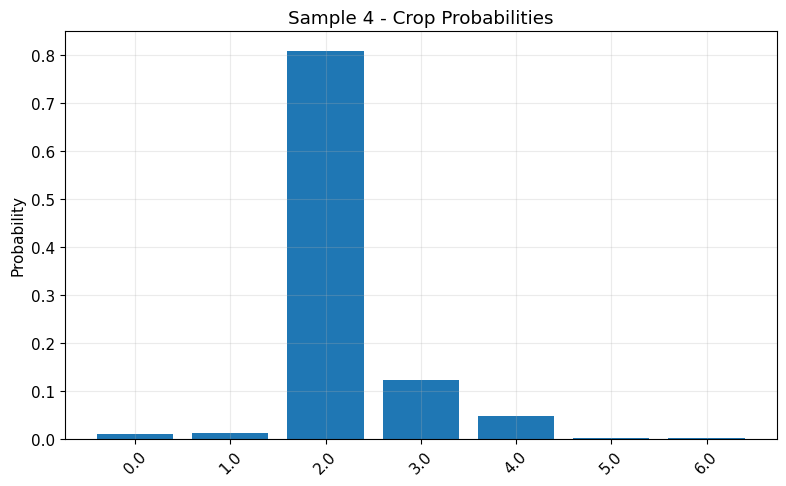

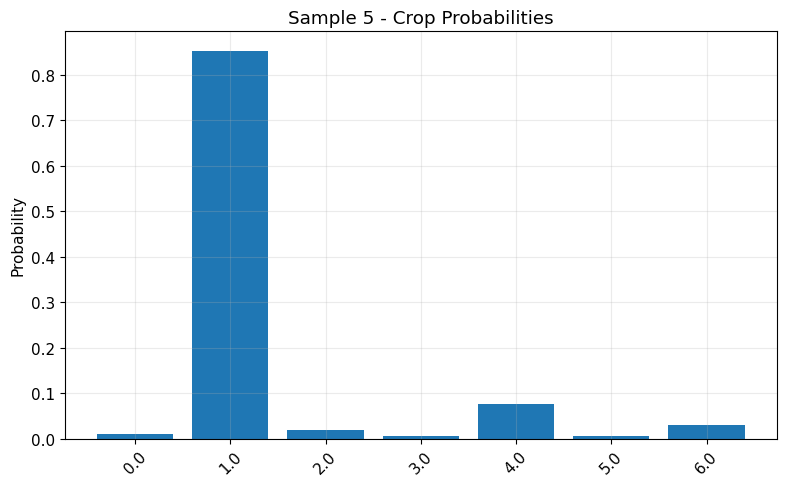

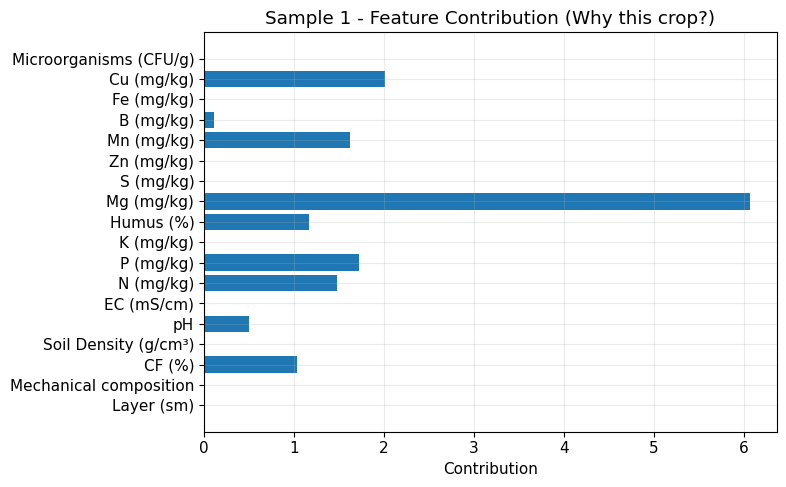

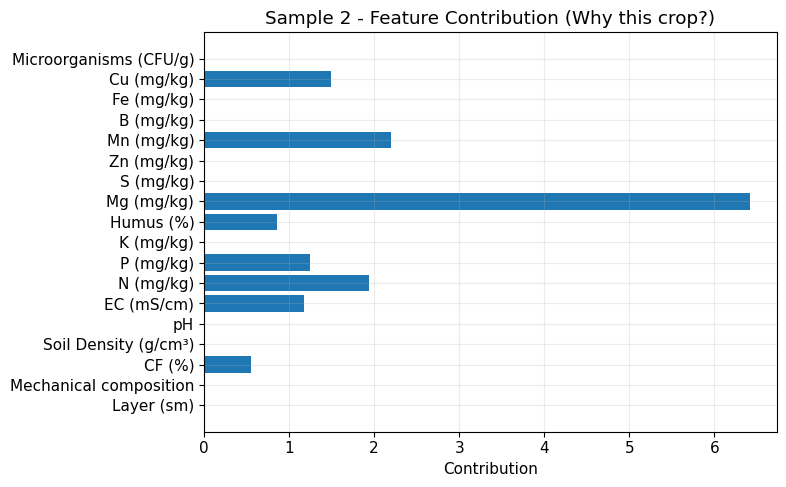

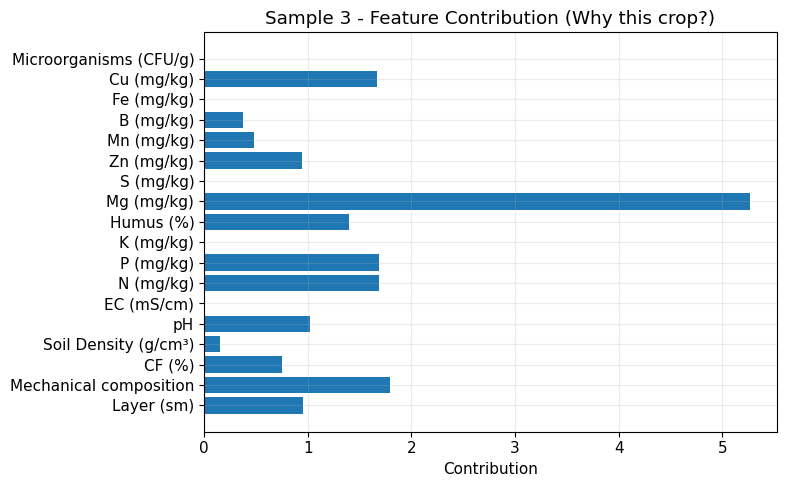

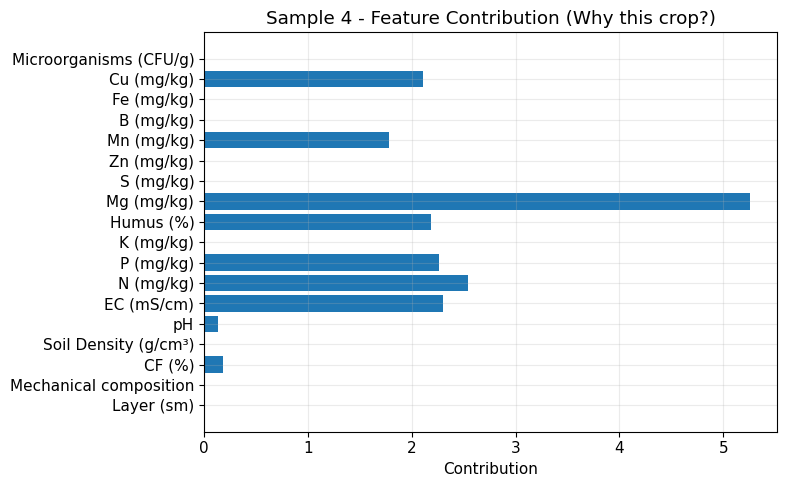

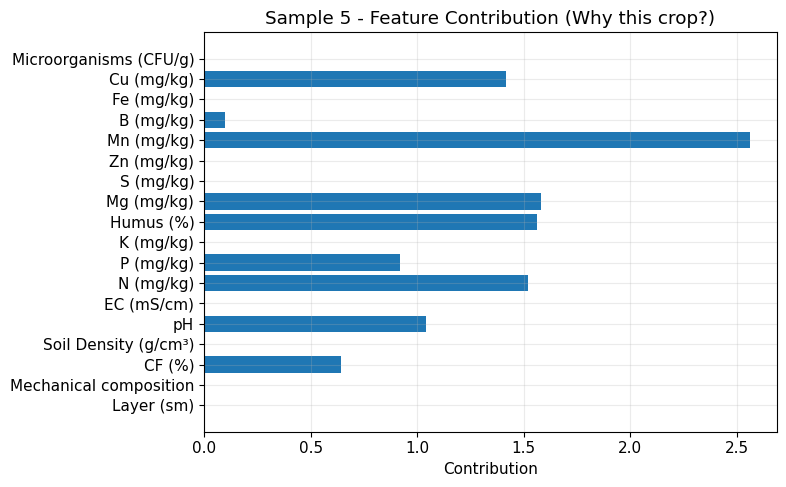

In [ ]:
# ================================
# 1) NEW SAMPLES (REAL FORMAT)
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

new_samples = pd.DataFrame([
    [3, "Loam", 28, 1.34, 6.88, 0.26, 49, 65, 51, 1.15, 88.0, 15, 1.2, 8.5, 0.6, 35, 0.8, 1401030],
    [2, "Sandy", 18, 0.3, 7.2, 1.30, 62, 37, 44, 1.28, 90, 10, 0.9, 6.5, 0.4, 28, 0.6, 233485],
    [3, "Clay", 32, 1.11, 7.69, 0.55, 95, 65, 72, 3.2, 113, 20, 1.5, 10.2, 0.8, 42, 1.0, 1.224426],
    [0, "Loam", 38, 0.20, 7.45, 2.40, 78, 52, 62, 0.8, 172, 18, 1.3, 9.0, 0.7, 38, 0.9, 9034022],
    [1, "Sandy", 31, 0.1, 7.25, 0.25, 50, 20, 30, 1.5, 8, 18, 0.7, 5.5, 0.3, 25, 0.5, 723422]
], columns=feature_cols)

# Identify categorical columns that the original 'encoder' was fitted on.
# Based on the notebook state, the encoder was fitted on object columns of the original df,
# which were ['Sample', 'Layer (sm)', 'Mechanical composition', 'Crop'].
categorical_cols_at_fit_time = ['Sample', 'Layer (sm)', 'Mechanical composition', 'Crop']

# Create a temporary DataFrame for encoding that includes all columns the encoder expects.
temp_df_for_encoding = pd.DataFrame(index=new_samples.index)

# Populate with existing categorical columns from new_samples (ensure string type).
if 'Layer (sm)' in new_samples.columns:
    temp_df_for_encoding['Layer (sm)'] = new_samples['Layer (sm)'].astype(str)
else:
    temp_df_for_encoding['Layer (sm)'] = 'UNKNOWN_LAYER' # Placeholder if missing

if 'Mechanical composition' in new_samples.columns:
    temp_df_for_encoding['Mechanical composition'] = new_samples['Mechanical composition'].astype(str)
else:
    temp_df_for_encoding['Mechanical composition'] = 'UNKNOWN_MECH' # Placeholder if missing

# Add dummy columns for 'Sample' and 'Crop' as they were part of original encoding but not in new_samples.
# These need to be strings as the encoder was fitted on string categories.
temp_df_for_encoding['Sample'] = 'UNKNOWN_SAMPLE'
temp_df_for_encoding['Crop'] = 'UNKNOWN_CROP'

# Ensure the order of columns matches what the encoder expects.
temp_df_for_encoding = temp_df_for_encoding[categorical_cols_at_fit_time]

# Apply the encoder transform to the temporary DataFrame.
encoded_values = encoder.transform(temp_df_for_encoding)

# Update the new_samples DataFrame with the encoded values for the relevant columns.
# 'Layer (sm)' is at index 1 and 'Mechanical composition' at index 2 in `categorical_cols_at_fit_time`.
new_samples['Layer (sm)'] = encoded_values[:, categorical_cols_at_fit_time.index('Layer (sm)')]
new_samples['Mechanical composition'] = encoded_values[:, categorical_cols_at_fit_time.index('Mechanical composition')]

# Re-initialize StandardScaler for features scaling, as the global `scaler` was overwritten.
# `X` (from notebook state) contains the unscaled features from the training data.
temp_feature_scaler = StandardScaler()
temp_feature_scaler.fit(X.copy()) # Fit on a copy of the original unscaled feature data X

new_samples_scaled = temp_feature_scaler.transform(new_samples)

pred_classes = clf.predict(new_samples_scaled)
pred_proba = clf.predict_proba(new_samples_scaled)

pred_labels = le.inverse_transform(pred_classes.astype(int))

# Get class names for plotting, ensuring they are strings
class_names_for_plot = [str(c) for c in le.classes_]

for i in range(len(new_samples)):
    probs = pred_proba[i]
    best_idx = np.argmax(probs)

    print(f"\n=== Sample {i+1} ===")
    print(f"Predicted Crop: {pred_labels[i]}")
    print(f"Confidence: {probs[best_idx]*100:.2f}%")


for i in range(len(new_samples)):
    plt.figure(figsize=(8,5))

    plt.bar(class_names_for_plot, pred_proba[i])
    plt.xticks(rotation=45)
    plt.title(f"Sample {i+1} - Crop Probabilities")
    plt.ylabel("Probability")

    plt.tight_layout()
    plt.show()


explain_matrix_new, masks_new = clf.explain(new_samples_scaled)

for i in range(len(new_samples)):
    plt.figure(figsize=(8,5))

    contrib = explain_matrix_new[i]

    plt.barh(feature_cols, contrib)
    plt.title(f"Sample {i+1} - Feature Contribution (Why this crop?)")
    plt.xlabel("Contribution")

    plt.tight_layout()
    plt.show()

In [ ]:
!jupyter nbconvert --to html Untitled8.ipynb


[NbConvertApp] Converting notebook Untitled8.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 27 image(s).
[NbConvertApp] Writing 2854505 bytes to Untitled8.html
